## 1. Setup and Import

In [1560]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import missingno as msno
from scipy.stats import pearsonr

## 2. Data Loading & Initial Inspection

We load the raw dataset into `raw_df` and immediately create `final_df` as the working copy. From this point on, `raw_df` is never modified — it always reflects the original CSV as provided.

In [1561]:
raw_df = pd.read_csv("ai_productivity_dataset_final.csv")
final_df = raw_df.copy()

raw_df.info()
raw_df.shape

<class 'pandas.DataFrame'>
RangeIndex: 3248 entries, 0 to 3247
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   task_id                3248 non-null   str    
 1   client                 3248 non-null   str    
 2   project_id             3248 non-null   str    
 3   client_tier            3248 non-null   str    
 4   team                   3248 non-null   str    
 5   task_type              3248 non-null   str    
 6   seniority              3248 non-null   str    
 7   task_complexity_score  3248 non-null   int64  
 8   brief_quality_score    3179 non-null   float64
 9   deadline_pressure      3248 non-null   str    
 10  scope_change_flag      3248 non-null   int64  
 11  pricing_model          3248 non-null   str    
 12  created_at             3248 non-null   str    
 13  delivered_at           3210 non-null   str    
 14  sla_days               3212 non-null   float64
 15  sla_breach     

(3248, 34)

In [1562]:
raw_df.describe()

,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,revisions,errors,rework_hours,outcome_score,revenue,cost,profit
count,3248.000000,3179.000000,3248.000000,3212.000000,3248.000000,3248.00000,3166.000000,3104.000000,3248.000000,3248.000000,3176.000000,3115.000000,3248.000000,3248.000000,3248.000000
mean,2.868842,3.183391,0.139163,5.012765,0.398091,13.05551,8.431563,0.361717,3.007697,1.014163,2.437543,68.856918,1120.571260,771.308146,349.263114
std,1.196459,1.211712,0.346169,2.520330,0.489580,11.55750,4.783216,0.199391,1.804829,1.042868,2.911421,12.642211,841.649433,584.269354,888.072715
min,1.000000,1.000000,0.000000,2.000000,0.000000,0.02000,-1.900000,0.000000,0.000000,0.000000,0.000000,9.000000,45.000000,77.850000,-8510.549511
25%,2.000000,2.000000,0.000000,3.000000,0.000000,7.91000,5.080000,0.200000,2.000000,0.000000,1.110000,60.870000,646.312500,440.805000,-2.610000
50%,3.000000,3.000000,0.000000,5.000000,0.000000,11.11500,7.535000,0.340000,3.000000,1.000000,1.810000,69.400000,966.430000,649.065000,254.645000
75%,4.000000,4.000000,0.000000,7.000000,1.000000,15.34500,10.687500,0.500000,4.000000,2.000000,2.950000,77.610000,1364.700000,941.145000,590.400000
max,5.000000,5.000000,1.000000,10.000000,1.000000,263.60018,47.020000,0.930000,11.000000,7.000000,57.517012,100.000000,14927.204324,9409.639511,14006.644324


### .describe() results: Data Quality Checks

From the summary statistics, a few inconsistencies emerge:
- Some variables contain extreme values, such as `hours_spent` and `profit`, which show large outliers compared to their typical range.
- In addition, `billable_hours` includes negative values, which are not meaningful and likely due to data issues or adjustments.
- There are also differences in the number of available observations across variables, indicating the presence of missing values.

Overall, while most variables appear reasonable, some cleaning and careful handling of outliers may be needed before further analysis.

In [1563]:
cat_df = raw_df.select_dtypes(exclude=["number"])
cat_df.describe()

,task_id,client,project_id,client_tier,team,task_type,seniority,deadline_pressure,pricing_model,created_at,delivered_at,ai_assisted,created_by,updated_at,task_status,workflow_stage,jira_ticket,legacy_ai_flag,content_version
count,3248,3248,3248,3248,3248,3248,3248,3248,3248,3248,3210,3248,3248,3248,3248,3248,2909,3248,3248
unique,3200,28,64,3,15,29,3,3,3,330,335,2,119,338,6,5,2868,3,5
top,T00010,Client_G,P028,mid,Content,design,mid,medium,hourly,2026-03-27,2026-01-18,True,user_026,2026-03-01,in_progress,qa,JIRA-53111,false,v1
freq,2,415,77,1514,803,456,1296,1482,1561,22,19,2561,44,20,1129,687,2,1458,926


### Categorical Variables Overview

From the summary statistics, a few relevant points emerge.

`delivered_at` contains some missing values, which is expected since not all tasks may have been completed.

`jira_ticket` also contain missing values.

`task_id` is not fully unique, suggesting the presence of duplicated entries or multiple records per task.

Finally, `created_at` and `updated_at` have a relatively low number of unique values compared to the dataset size, indicating that many records share the same timestamps.

### 2.1 Duplicate & Identifier Check

We verify whether any rows are fully duplicated and whether `task_id` contains repeated values. Repeated `task_id` entries are inspected to determine if they belong to the same client (likely data versioning) or to different clients (data integrity issue).

In [1564]:
# checking if there are duplicated rows
print(final_df.duplicated().sum())

# lista di quali task_id si ripetono due volte
task_id_counts = final_df["task_id"].value_counts()
task_id_repeated = task_id_counts[task_id_counts == 2].index.tolist()
task_id_repeated

0


['T00010',
 'T00139',
 'T00170',
 'T00205',
 'T00219',
 'T00285',
 'T00343',
 'T00413',
 'T00460',
 'T00608',
 'T00617',
 'T00675',
 'T00721',
 'T00726',
 'T00748',
 'T00759',
 'T00875',
 'T00881',
 'T00885',
 'T01075',
 'T01080',
 'T01148',
 'T01151',
 'T01162',
 'T01236',
 'T01344',
 'T01359',
 'T01400',
 'T01476',
 'T01516',
 'T01740',
 'T01849',
 'T01852',
 'T01881',
 'T01915',
 'T01988',
 'T02060',
 'T02075',
 'T02118',
 'T02191',
 'T02295',
 'T02307',
 'T02344',
 'T02652',
 'T02689',
 'T02958',
 'T03121',
 'T03155']

In [1565]:
#Verifica che ogni task_id di task_id_repeated appartenga allo stesso client 
for task_id in task_id_repeated:
    client_ids = final_df[final_df["task_id"] == task_id]["client"].unique()
    if len(client_ids) > 1:
        print(f"Task ID {task_id} belongs to multiple clients: {client_ids}")

Task ID T00010 belongs to multiple clients: <StringArray>
['Client_F', 'Client_J']
Length: 2, dtype: str
Task ID T00726 belongs to multiple clients: <StringArray>
['Client_[', 'Client_F']
Length: 2, dtype: str
Task ID T00875 belongs to multiple clients: <StringArray>
['Client_C', 'Client_W']
Length: 2, dtype: str
Task ID T01080 belongs to multiple clients: <StringArray>
['Client_D', 'Client_M']
Length: 2, dtype: str
Task ID T01740 belongs to multiple clients: <StringArray>
['Client_A', 'Client_S']
Length: 2, dtype: str
Task ID T02295 belongs to multiple clients: <StringArray>
['Client_W', 'Client_K']
Length: 2, dtype: str


## 3. Categorical Variable Cleaning

Several categorical columns contain label inconsistencies (typos, mixed case, alternate naming conventions). We standardise each one before any analysis.

### 3.1 `team`

Lowercasing, stripping whitespace, and correcting typos (`contennt` → `content`, `desgn` → `design`).

In [1566]:
final_df["team"].value_counts()

# team is used to classify the different teams working on the projects
# we can obsserve that there are some repetitions and errors so I need to fix them

final_df["team"] = final_df["team"].str.lower()
final_df["team"] = final_df["team"].str.strip()

# I need to convert the value "contennt" to "content" in the team name column
final_df["team"] = final_df["team"].replace("contennt", "content")
final_df["team"] = final_df["team"].replace("desgn", "design")

# paid_media has significantly fewer observations than media — merging into media 
final_df["team"] = final_df["team"].replace("paid media", "media") 
final_df["team"].value_counts()

team
content    835
media      821
design     798
seo        794
Name: count, dtype: int64

### 3.2 `task_type`

Lowercasing, stripping, and consolidating multiple label variants into canonical categories.

In [1567]:
# we need to clean the task_type column as well
final_df["task_type"] = final_df["task_type"].str.lower()
final_df["task_type"] = final_df["task_type"].str.strip()

final_df["task_type"] = final_df["task_type"].replace("relese", "release")
final_df["task_type"] = final_df["task_type"].replace("release_task", "release")
final_df["task_type"] = final_df["task_type"].replace("dev_task", "dev")
final_df["task_type"] = final_df["task_type"].replace("ad_task", "ad")
final_df["task_type"] = final_df["task_type"].replace("article_task", "article")
final_df["task_type"] = final_df["task_type"].replace("artcle", "article")
final_df["task_type"] = final_df["task_type"].replace("repport", "report")
final_df["task_type"] = final_df["task_type"].replace("report_task", "report")
final_df["task_type"] = final_df["task_type"].replace("design_task", "design")
final_df["task_type"] = final_df["task_type"].replace("ticket_task", "ticket")
final_df["task_type"] = final_df["task_type"].replace("dev", "development")

# merge low-frequency subcategories into their parent categories  
final_df["task_type"] = final_df["task_type"].replace("blog_article", "article")  
final_df["task_type"] = final_df["task_type"].replace("paid_ad", "ad")  
final_df["task_type"] = final_df["task_type"].replace("support_ticket", "ticket")  
final_df["task_type"] = final_df["task_type"].replace("creative", "design")  
final_df["task_type"].value_counts()

task_type
design         478
ad             474
ticket         473
article        468
report         466
development    446
release        443
Name: count, dtype: int64

### 3.3 Remaining Variables — Value Inspection

No cleaning was required for the remaining categorical columns. We inspect them to confirm label consistency and understand their distributions.

In [1568]:
final_df["client_tier"].value_counts()
# client tier is used to classify the "importance" in terms of value/revenues of the different clients

client_tier
mid     1514
low      877
high     857
Name: count, dtype: int64

In [1569]:
final_df["seniority"].value_counts()

seniority
mid       1296
junior    1190
senior     762
Name: count, dtype: int64

In [1570]:
final_df["deadline_pressure"].value_counts()

deadline_pressure
medium    1482
low        914
high       852
Name: count, dtype: int64

In [1571]:
final_df["pricing_model"].value_counts()

pricing_model
hourly         1561
fixed          1227
value_based     460
Name: count, dtype: int64

In [1572]:
final_df["task_status"].value_counts()

task_status
in_progress    1129
review          866
delivered       769
draft           183
archived        151
blocked         150
Name: count, dtype: int64

In [1573]:
final_df["workflow_stage"].value_counts()

workflow_stage
qa               687
client_review    664
finalized        643
briefing         640
execution        614
Name: count, dtype: int64

In [1574]:
final_df["content_version"].value_counts()

content_version
v1       926
v2       775
v3       667
final    560
v4       320
Name: count, dtype: int64

In [1575]:
final_df["legacy_ai_flag"].value_counts()

legacy_ai_flag
false      1458
true       1451
unknown     339
Name: count, dtype: int64

In [1576]:
final_df["scope_change_flag"].value_counts()  
#it may mean that the scope of the task has changed during its execution    

scope_change_flag
0    2796
1     452
Name: count, dtype: int64

In [1577]:
final_df["sla_breach"].value_counts()

sla_breach
0    1955
1    1293
Name: count, dtype: int64

In [1578]:
# The "jira_ticket" variable represents a unique identifier linking each task to its corresponding record in the Jira system.
# The 'jira_ticket' column contains approximately 10% missing values, representing tasks not tracked in the Jira system.
# As this variable is an identifier and does not provide predictive information, it was excluded from further analysis.
final_df["jira_ticket"].value_counts()

jira_ticket
JIRA-53111    2
JIRA-67759    2
JIRA-38743    2
JIRA-62438    2
JIRA-36863    2
             ..
JIRA-42947    1
JIRA-90491    1
JIRA-19154    1
JIRA-32851    1
JIRA-39958    1
Name: count, Length: 2868, dtype: int64

## 4. Date Variables Conversion

The columns `created_at`, `delivered_at`, and `updated_at` are stored as strings and must be converted to datetime objects to enable time-based feature engineering.

In [1579]:
# I need to convert "created_at", "delivered_at" and "updated_at" to datetime since they are str
final_df["created_at"] = pd.to_datetime(final_df["created_at"], errors="coerce")
final_df["delivered_at"] = pd.to_datetime(final_df["delivered_at"], errors="coerce")
final_df["updated_at"] = pd.to_datetime(final_df["updated_at"], errors="coerce")
final_df[["created_at", "delivered_at", "updated_at"]].head()

,created_at,delivered_at,updated_at
0,2025-11-20,2025-11-25,2025-11-28
1,2026-01-24,2026-01-26,2026-01-26
2,2025-09-16,2025-09-23,2025-09-17
3,2025-11-06,2025-11-09,2025-11-12
4,2026-05-02,2026-05-06,2026-05-09


## 5. Missing Value Treatment

We first visualise the overall missing value pattern, then treat each affected column individually with a justified imputation strategy.

In [1580]:
# checking the missing values for each column
missing_values = final_df.isnull().sum()
missing_percentage = (missing_values / final_df.shape[0]) * 100

missing_summary = pd.DataFrame({"count": missing_values, "pct": missing_percentage})
missing_summary[missing_summary["count"] > 0]
# columns that contain missing: brief_quality_score, delivered_at, sla_days, billable_hours, ai_usage_pct, rework_hours, outcome_score, jira_ticket

,count,pct
brief_quality_score,69,2.124384
delivered_at,38,1.169951
sla_days,36,1.108374
billable_hours,82,2.524631
ai_usage_pct,144,4.433498
rework_hours,72,2.216749
outcome_score,133,4.094828
jira_ticket,339,10.437192


<Axes: >

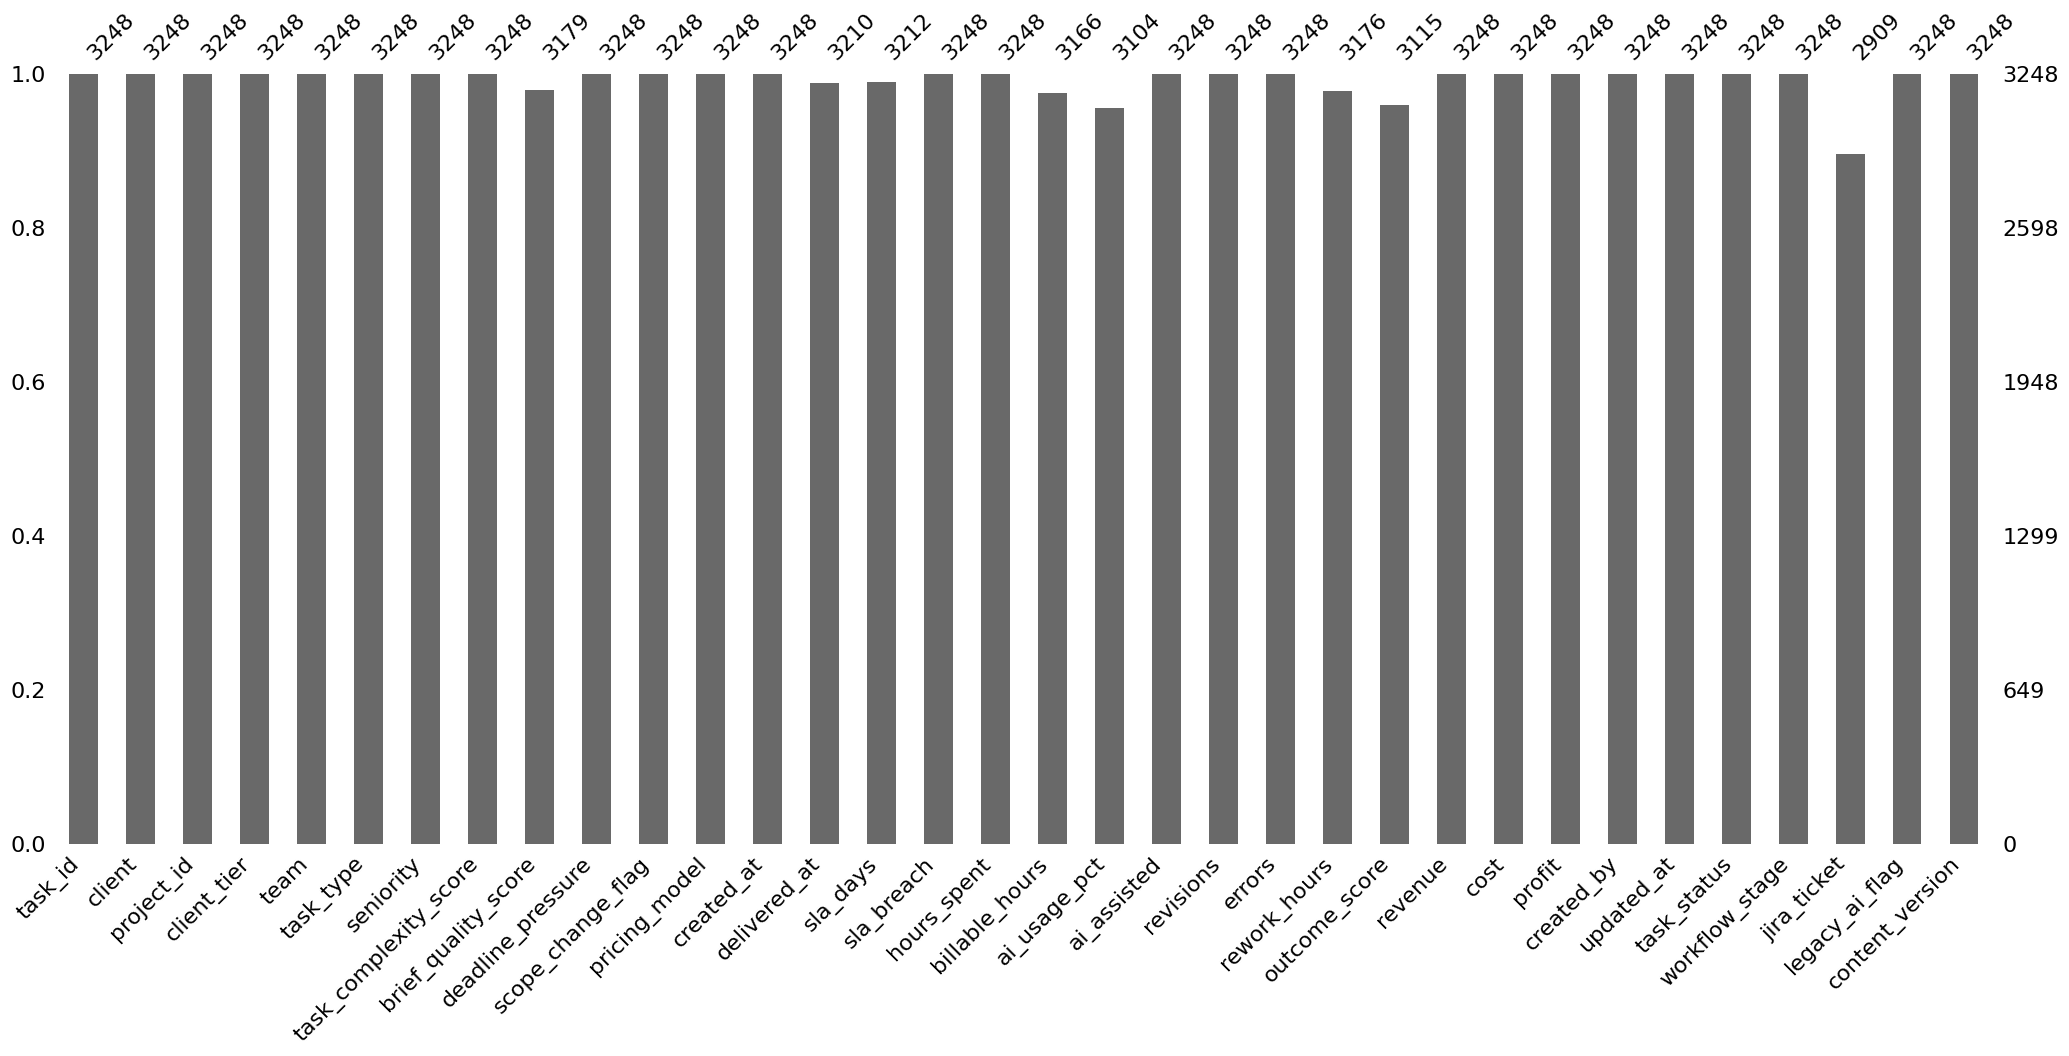

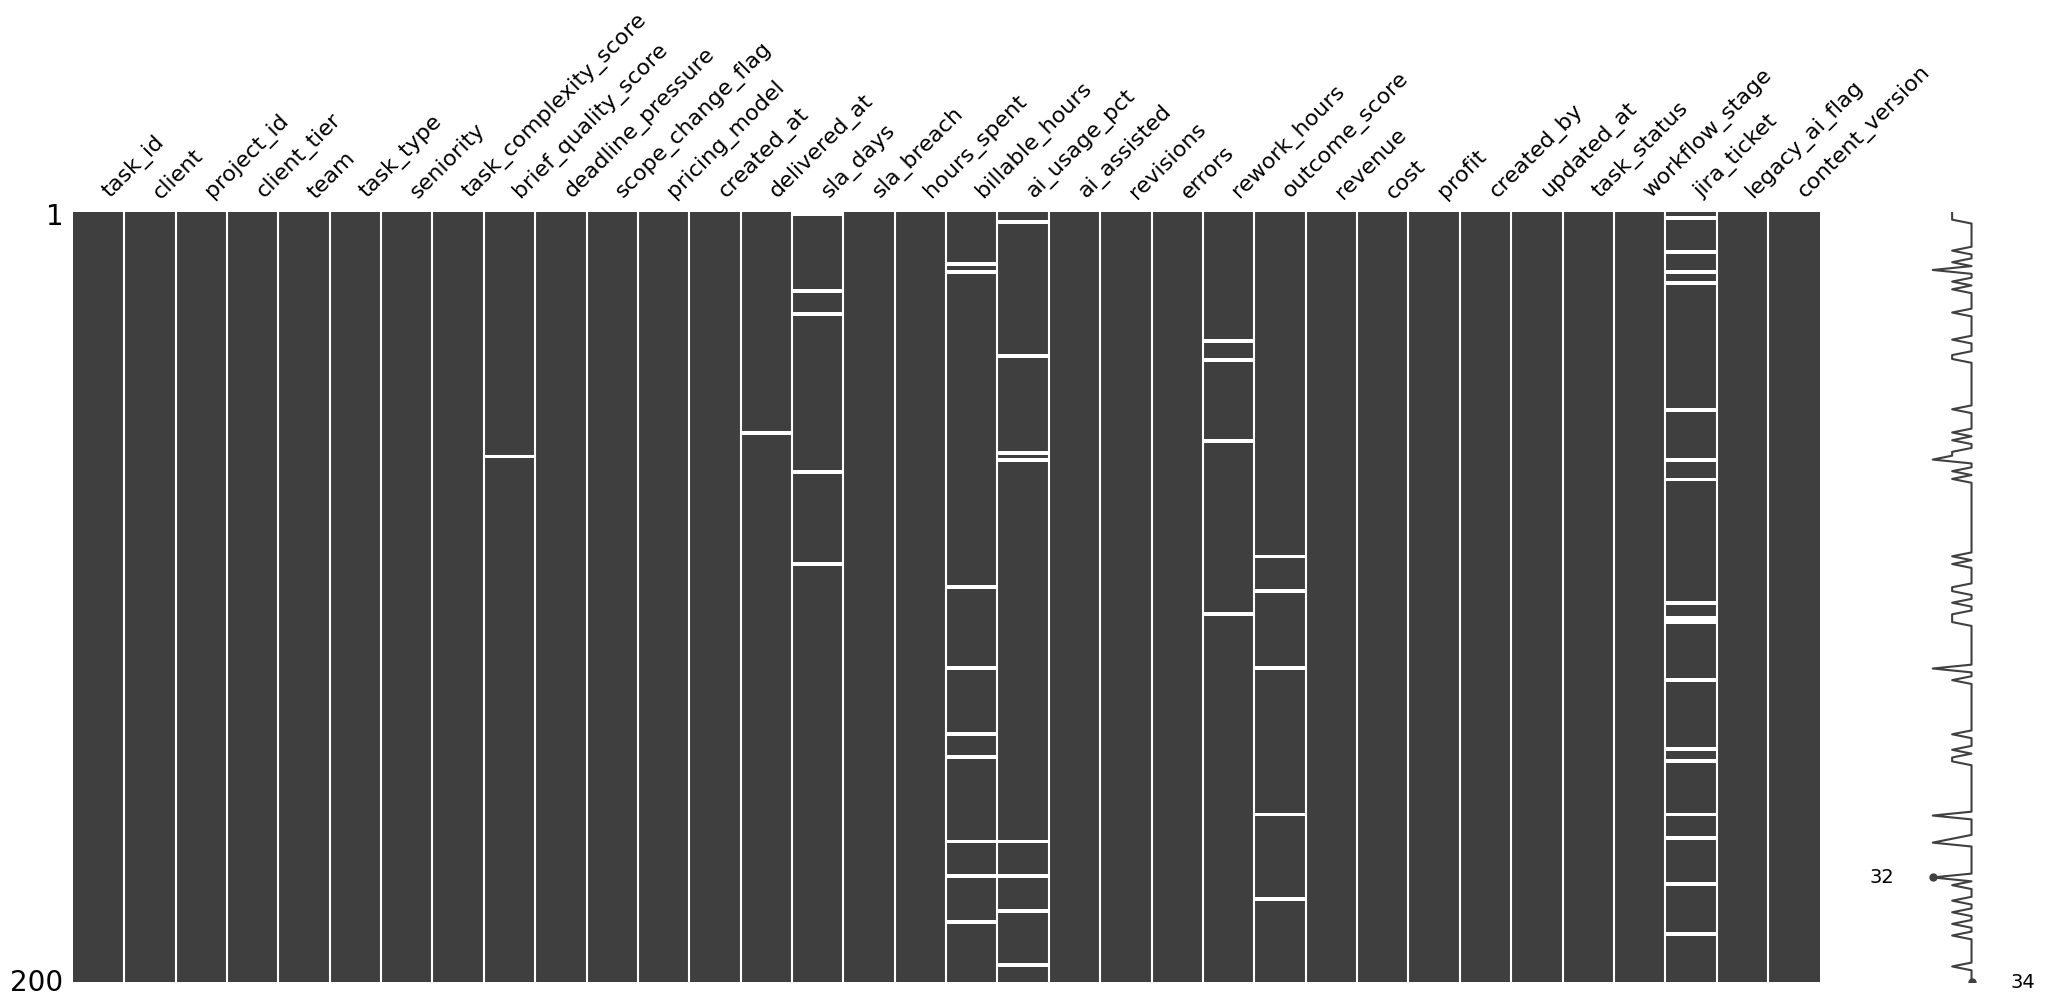

In [1581]:
# visualization of columns that contain missing values
msno.bar(final_df)
msno.matrix(final_df.sample(200))

### 5.1 `brief_quality_score` — Median imputation (MCAR)

~2.1% of values are missing. A comparison of key metrics between rows with and without missing `brief_quality_score` shows near-identical means, indicating Missing Completely At Random (MCAR). We impute with the overall median.

In [1582]:
final_df["missing_flag"] = final_df["brief_quality_score"].isna().astype(int)
final_df.groupby("missing_flag").mean(numeric_only=True)

# An analysis comparing missing vs non missing observations showed that missing values are almost completely at random (MCAR)
# as they are associated with very little differences in variables such as task duration, SLA breach and scope

,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,ai_assisted,revisions,errors,rework_hours,outcome_score,revenue,cost,profit
missing_flag,,,,,,,,,,,,,,,,
0,2.872287,3.183391,0.137779,5.007952,0.397295,13.034793,8.456453,0.362091,0.789242,3.012583,1.019188,2.433118,68.831279,1120.871426,773.545388,347.326038
1,2.710145,NaN,0.202899,5.235294,0.434783,14.010008,7.297647,0.344776,0.753623,2.782609,0.782609,2.639808,70.041364,1106.741895,668.232899,438.508997


In [1583]:
final_df["brief_quality_score"] = final_df["brief_quality_score"].fillna(final_df["brief_quality_score"].median())

### 5.2 `delivered_at` — True missing (for now no imputation)

I check whether missing values in `delivered_at` are due to errors or simply tasks not yet delivered. Since tasks not marked as delivered can still have a valid `delivered_at`, the missingness appears to be genuine.
I do not handle it at this stage. The few inconsistent cases (tasks marked as delivered but with missing `delivered_at`) will be addressed later when computing delivery time, by imputing `delivered_at` using the average delivery duration.

In [1584]:
missing_values = final_df[final_df["delivered_at"].isnull()]["task_status"].value_counts()
missing_values

task_status
delivered      13
in_progress    12
review          7
archived        4
blocked         1
draft           1
Name: count, dtype: int64

In [1585]:
final_df[final_df["task_status"] != "delivered"]["delivered_at"].notna().sum()
# As we can see from the analysis above, there are observations with "delivered_at" not null but with "task_status" different from "delivered",
# so the missingness are true missing

np.int64(2454)

### 5.3 `sla_days` — Median imputation (MCAR)

Missing rows show no systematic pattern across other variables. Missingness is treated as MCAR and imputed with the overall median.

In [1586]:
# I can inpute sla_days missings with the median since the missings are completely at random
final_df["sla_days"] = final_df["sla_days"].fillna(final_df["sla_days"].median())

### 5.4 `billable_hours` — Group-based median imputation

~2.5% of values are missing. Inspection confirms these are true missing values, not zero-billable tasks. A group-based median imputation by `pricing_model` and `task_type` is applied to preserve business structure, followed by a global median fallback for any remaining cases.

In [1587]:
final_df[final_df["billable_hours"].isna()][["task_status", "pricing_model", "hours_spent", "revenue", "cost", "profit"]].head(50)
final_df["billable_hours"] = final_df.groupby(["pricing_model", "task_type"])["billable_hours"].transform(lambda x: x.fillna(x.median()))

final_df["billable_hours"] = final_df["billable_hours"].fillna(final_df["billable_hours"].median())

# Missing values in "billable_hours" were analyzed and found to be true missing data rather than non-billable tasks and as highlighted before only 2.52% of the column's values.
# A group-based median imputation (by pricing_model and task_type) was applied to preserve business structure, followed by a global median fallback for remaining cases (only one obs).

### 5.5 `ai_usage_pct` — Median imputation (MCAR)

~4.5% of values are missing. The missing rate is similar across `legacy_ai_flag` groups, ruling out a systematic relationship. Analysis of legacy tasks shows a median AI usage of ~34%, confirming that missing values do not represent absence of AI. We impute with the overall median.

In [1588]:
final_df[final_df["legacy_ai_flag"] == "true"]["ai_usage_pct"].describe()
# An analysis of "ai_usage_pct" within legacy tasks showed a median usage of 0.34%, indicating that AI was actively used even in legacy data.
# Therefore, missing values do not represent absence of AI usage but rather missing information.

count    1381.000000
mean        0.365243
std         0.202176
min         0.010000
25%         0.200000
50%         0.340000
75%         0.510000
max         0.930000
Name: ai_usage_pct, dtype: float64

In [1589]:
final_df.groupby("legacy_ai_flag")["ai_usage_pct"].apply(lambda x: x.isna().mean())

# An analysis of missing values in 'ai_usage_pct' (4.5%) showed no significant differences across 'legacy_ai_flag' categories,
# indicating that missingness is not related to legacy system usage. For this reason I can inpute using the median.

final_df["ai_usage_pct"] = final_df["ai_usage_pct"].fillna(final_df["ai_usage_pct"].median())

### 5.6 `rework_hours` — Median imputation (true missing)

~2.2% of values are missing. Since `rework_hours` can be positive even when `errors = 0` and `revisions = 0`, missing values cannot be interpreted as zero. They are treated as true missing and imputed with the median.

In [1590]:
final_df[final_df["rework_hours"].isna()][["errors", "revisions","task_status", "outcome_score"]].head(50)

,errors,revisions,task_status,outcome_score
47,1,3,in_progress,77.98
82,0,2,in_progress,68.17
89,2,4,delivered,55.63
138,0,4,review,71.45
158,0,3,delivered,86.61
160,0,4,in_progress,75.92
176,4,1,in_progress,79.97
203,1,0,delivered,43.72
219,0,7,delivered,73.94
221,1,1,delivered,55.59


In [1591]:
final_df[final_df["errors"] == 0]["rework_hours"].describe()
final_df[final_df["revisions"] == 0]["rework_hours"].describe()

count    168.000000
mean       1.782202
std        1.338072
min        0.000000
25%        0.935000
50%        1.485000
75%        2.297500
max        8.310000
Name: rework_hours, dtype: float64

In [1592]:
final_df["rework_hours"] = final_df["rework_hours"].fillna(final_df["rework_hours"].median())

# since missing "rework_hours" represent only 2,2% of the total data and "rework_hours" are present when no errors/revisions are made, missing values cannot be interpreted as 0.
# For these reasons they were treated as true missing data

### 5.7 `outcome_score` — Median imputation (MCAR)

Missing `outcome_score` does not depend on `task_status` or `workflow_stage`, confirming MCAR. We impute with the overall median.

In [1593]:
final_df.groupby("task_status")["outcome_score"].describe()
final_df[final_df["outcome_score"].isna()][["task_status", "workflow_stage", "delivered_at"]].head(50)

# since outcome_score does not depend on task_status or workflow_stage, we can use the overall median
final_df["outcome_score"] = final_df["outcome_score"].fillna(final_df["outcome_score"].median())

### 5.8 Final Missing Value Check

After all imputations, we verify that no treatable missing values remain.

In [1594]:
missing_values = final_df.isnull().sum()
missing_values[missing_values > 0]

delivered_at     38
jira_ticket     339
dtype: int64

## 6. Exploratory Data Analysis (EDA)

We explore distributions and relationships through a correlation heatmap, histograms of key numeric variables, countplots for categorical variables, and boxplots comparing categories against the main outcome variables.

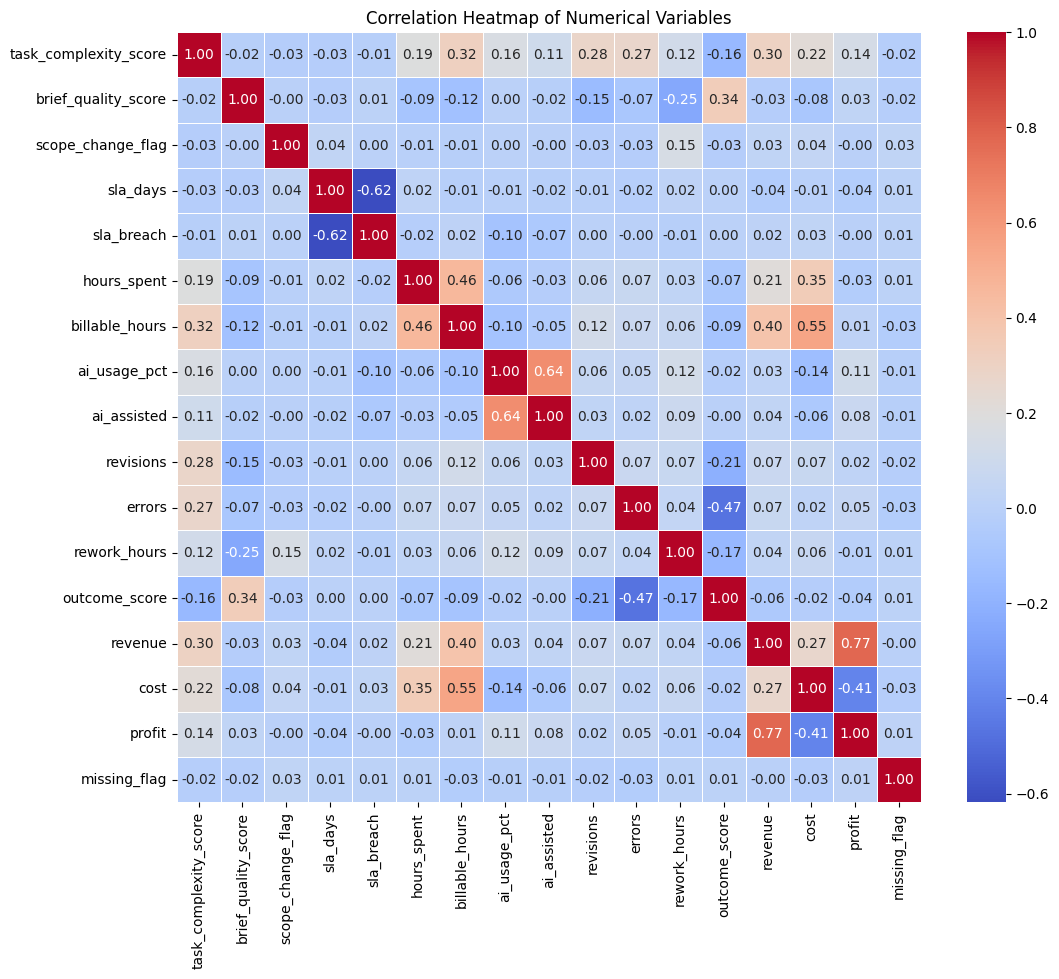

In [1595]:
#heatmap of correlation between numerical variables
plt.figure(figsize=(12, 10))
sns.heatmap(final_df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

#the most correlated variables are billable_hours and cost (0.55), ai_usage_pct and ai_assisted (0.64) and revenue and profit (0.77)
#while sla_days and sla_breach are negatively correlated (-0.62) and also error and outcome_score(-0.47)but also cost 

In [1596]:
num_cols = final_df.select_dtypes(include=np.number).columns.tolist()
num_cols

['task_complexity_score',
 'brief_quality_score',
 'scope_change_flag',
 'sla_days',
 'sla_breach',
 'hours_spent',
 'billable_hours',
 'ai_usage_pct',
 'revisions',
 'errors',
 'rework_hours',
 'outcome_score',
 'revenue',
 'cost',
 'profit',
 'missing_flag']

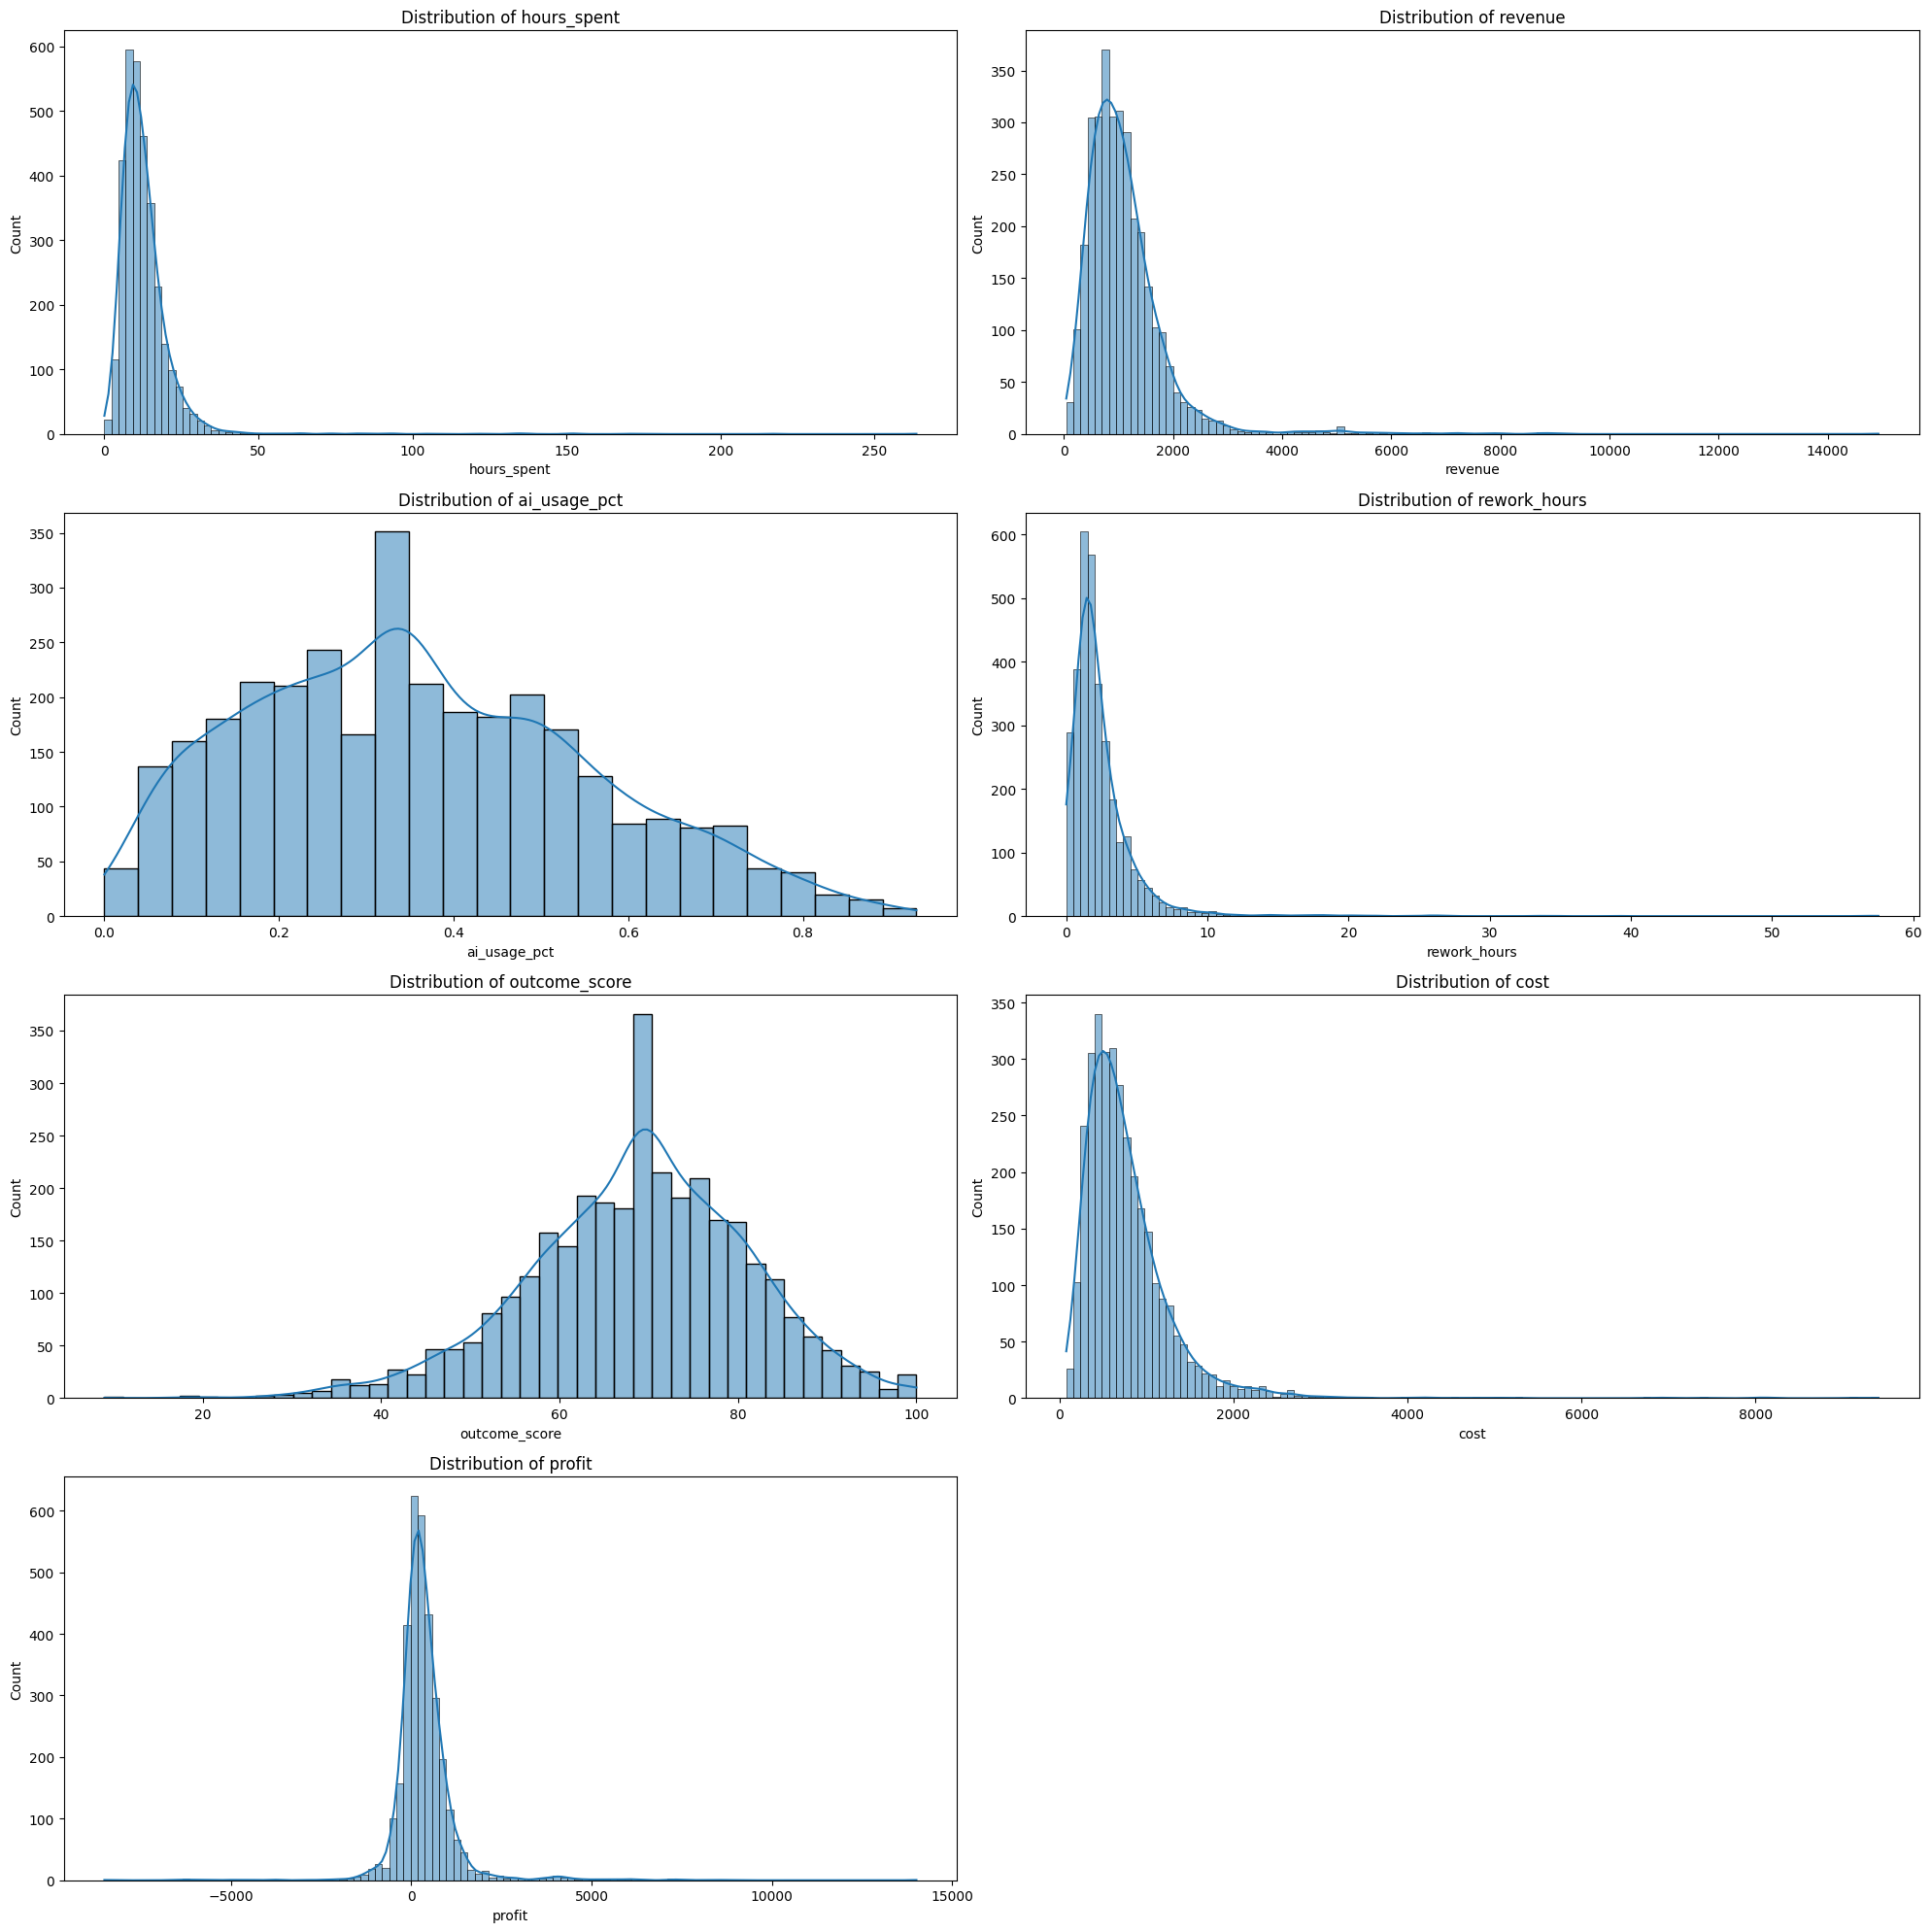

In [1597]:
#distribution of hours_spent, revenue, ai_usage_pct, rework_hours, outcome_score, cost and profit
plt.figure(figsize=(20, 20))
cols_to_plot = ["hours_spent", "revenue", "ai_usage_pct", "rework_hours", "outcome_score", "cost", "profit"]
for i, col in enumerate(cols_to_plot):
    plt.subplot(4, 2, i + 1)
    sns.histplot(final_df[col], kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

Distribution observations:
- The variables `hours_spent`, `billable_hours`, `rework_hours`, `revenue`, and `cost` show strong right-skewness with obvious outliers. A log transformation may be necessary before modeling.
- `scope_change_flag` and `sla_breach` are binary and unbalanced.
- `outcome_score` has an approximately left-normal distribution, suitable as a target variable.
- `profit` has a bimodal distribution with both positive and negative values, suggesting the existence of structurally different task segments.

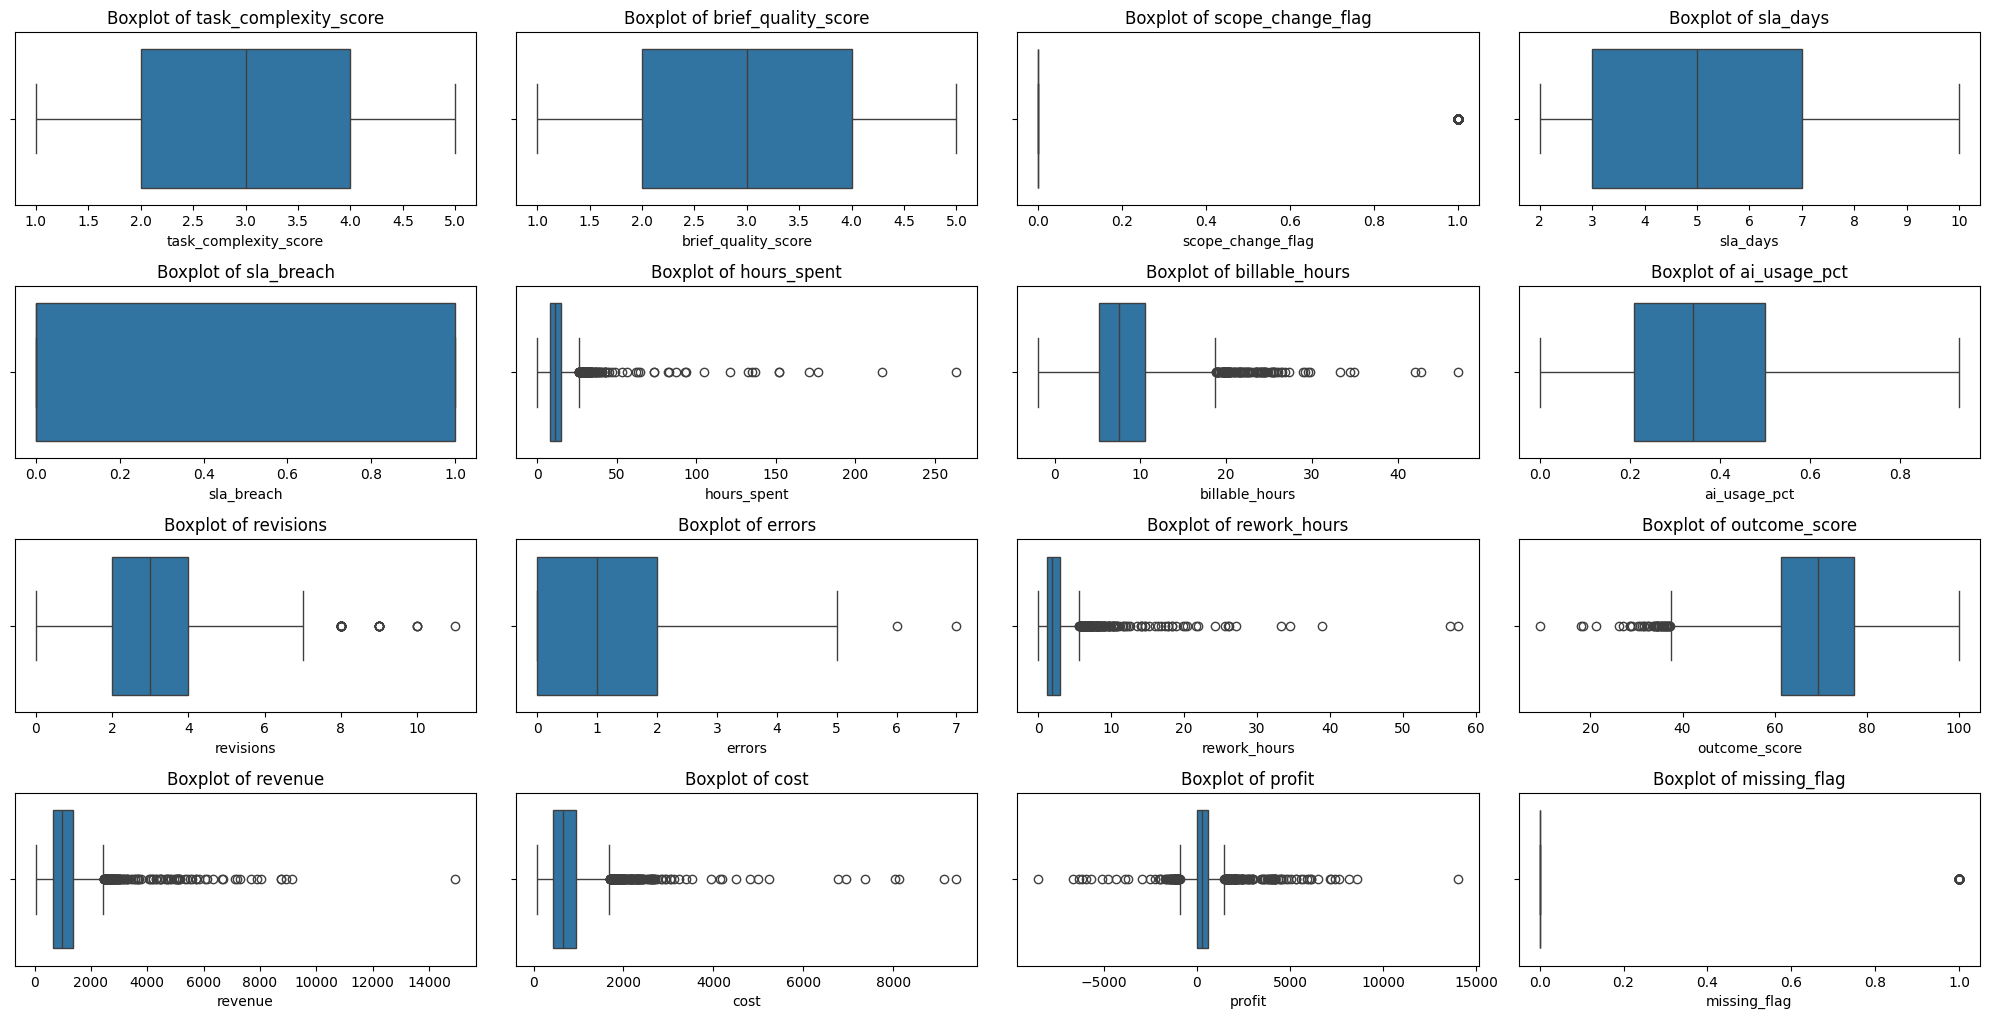

In [1598]:
#boxplot for numerical columns 
plt.figure(figsize=(20, 20))
for i, col in enumerate(num_cols):
    plt.subplot(8, 4, i + 1)
    sns.boxplot(x=final_df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

In [1599]:
cat_cols = ["team", "task_type", "seniority", "task_status", 
            "workflow_stage", "client_tier", "pricing_model", 
            "deadline_pressure", "ai_assisted", "legacy_ai_flag",
            "scope_change_flag", "content_version"]

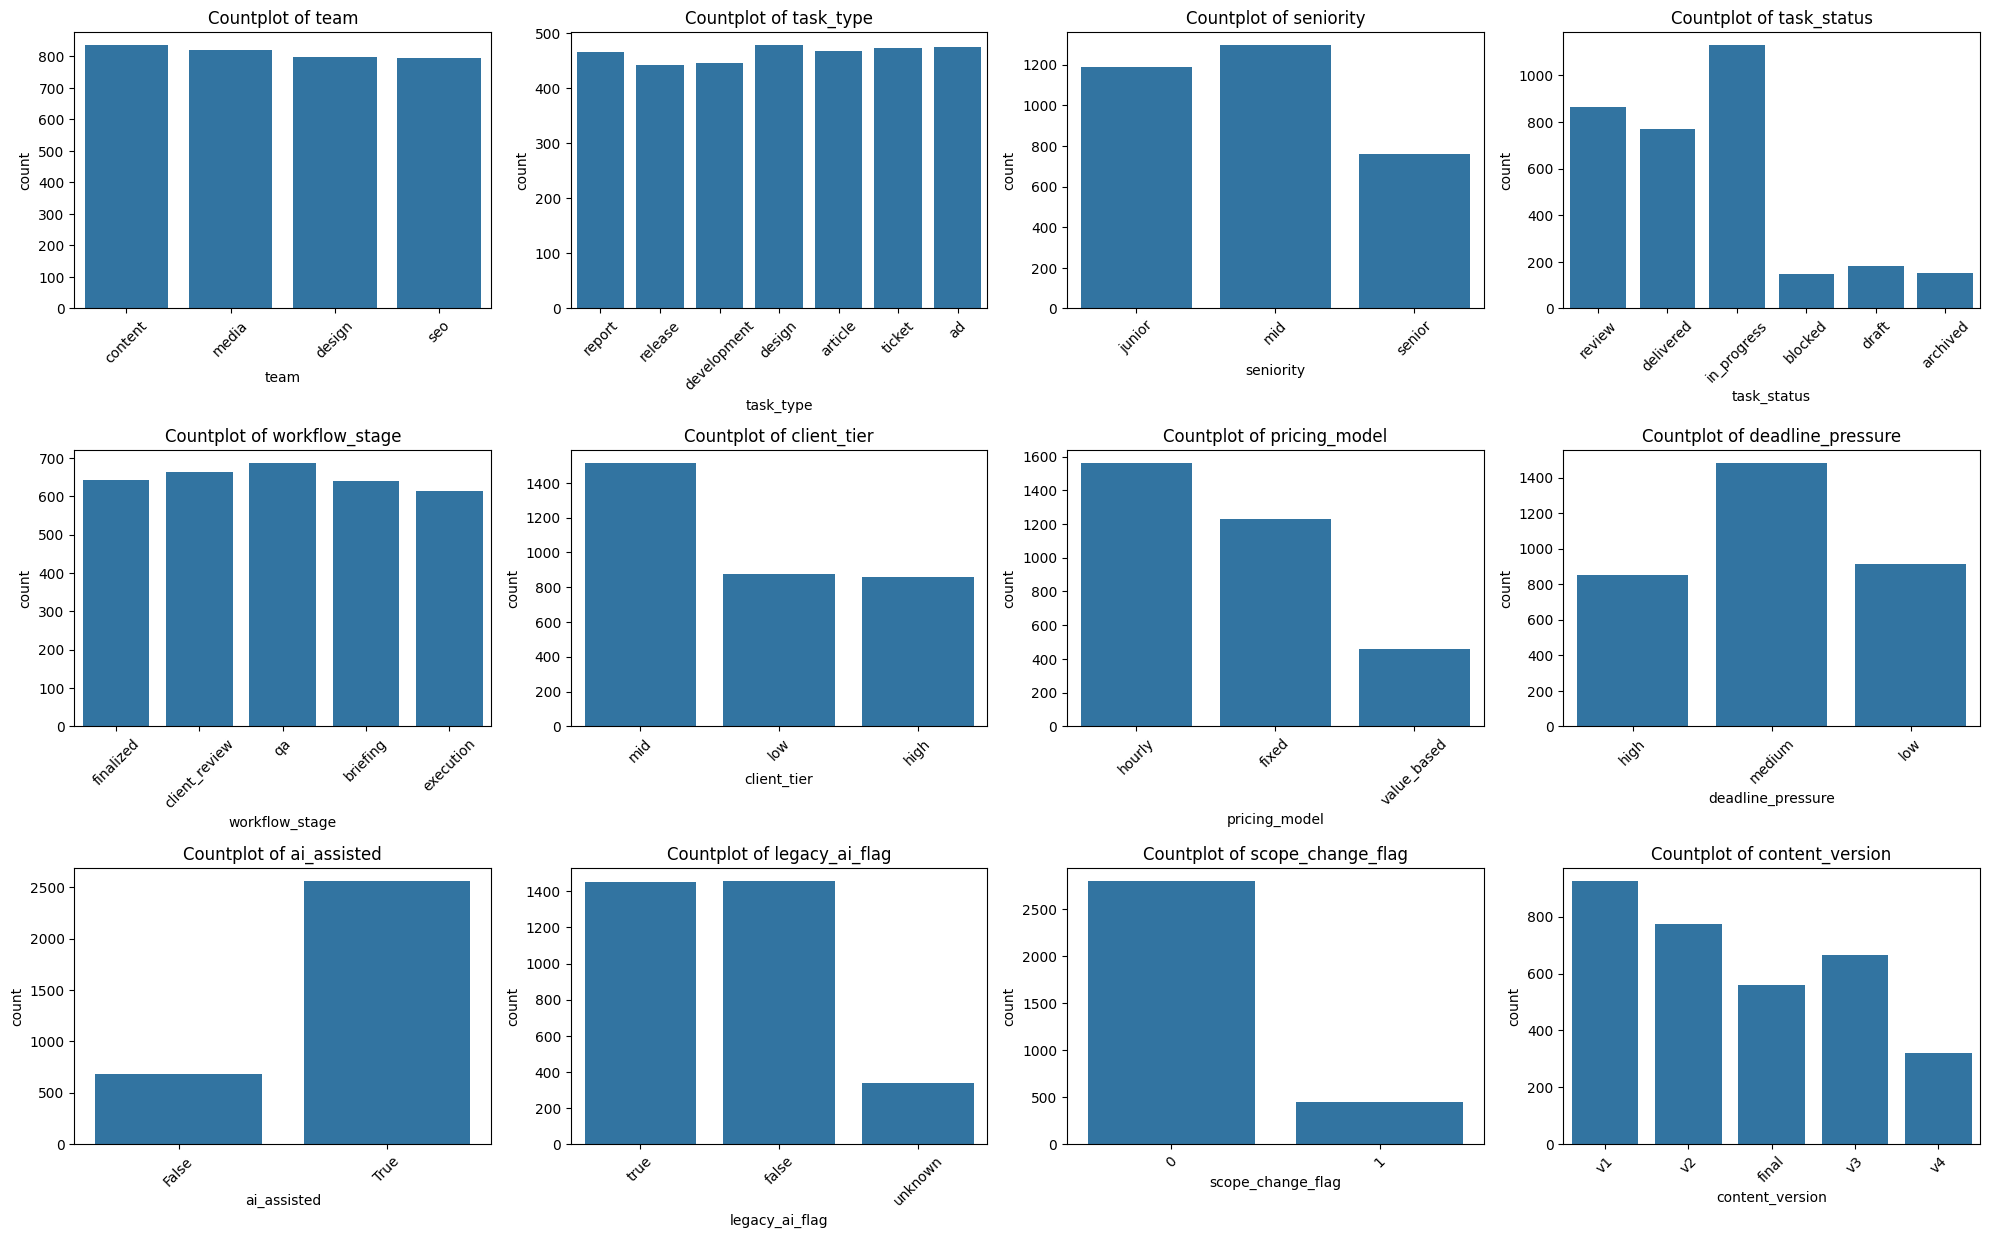

In [1600]:
#only an image with all this plots together
plt.figure(figsize=(20, 20))
for i, col in enumerate(cat_cols):
    plt.subplot(5, 4, i + 1)
    sns.countplot(data=final_df, x=col)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)     
plt.tight_layout()
plt.show()

Categorical distribution notes:
- **TEAM:** `paid_media` has significantly fewer observations than `media` — consider merging.
- **TASK_TYPE:** Several low-frequency categories (`creative`, `blog_article`, `paid_ad`) — consider consolidating with larger groups.
- **SENIORITY:** Unbalanced distribution with significantly more junior and mid-level than senior staff. Normal in an agency context, but must be accounted for to avoid over- or underestimating the seniority effect.

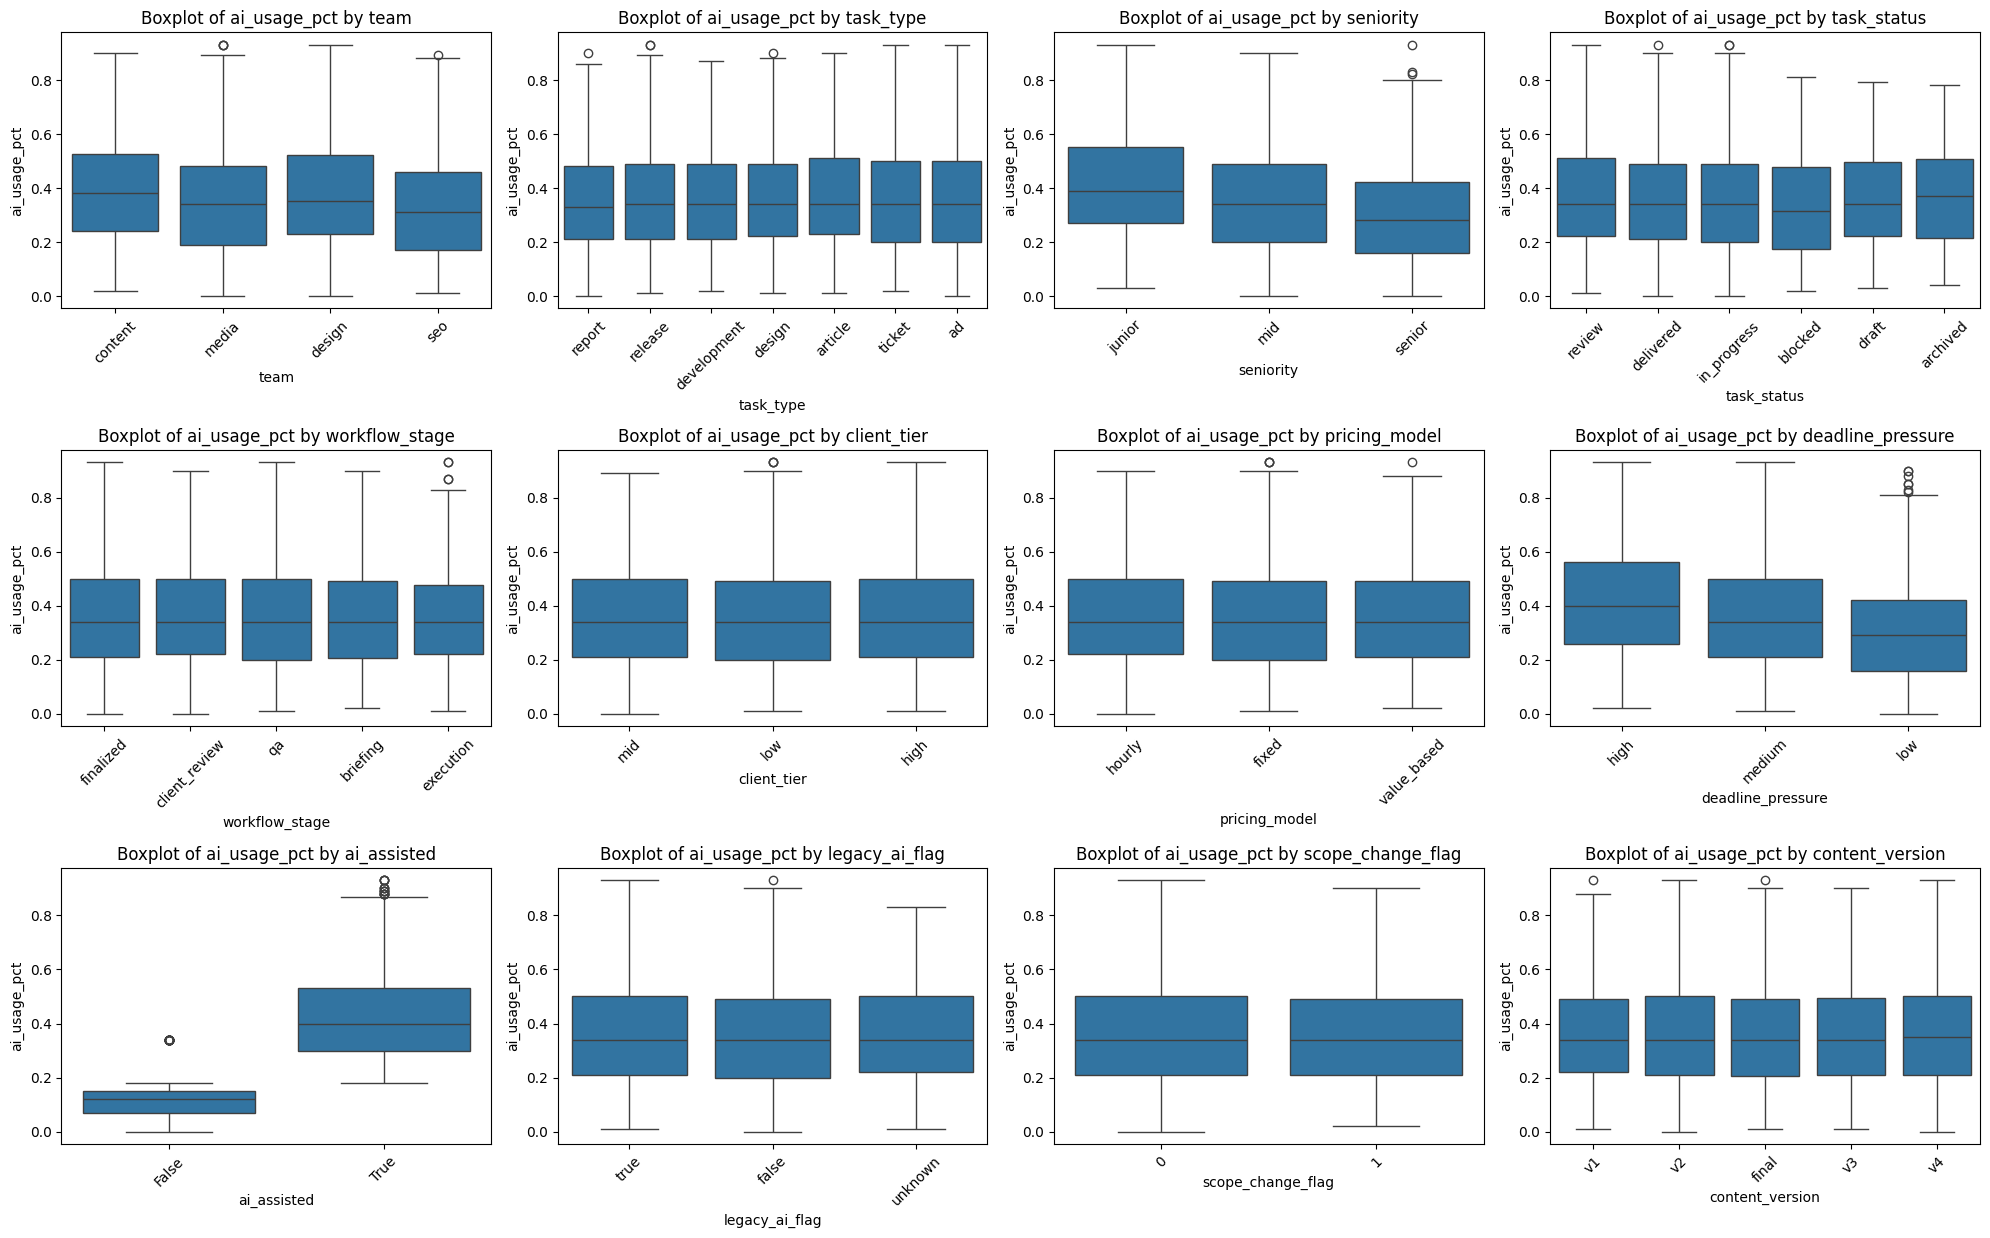

In [1601]:
#boxplot for categorical variables
plt.figure(figsize=(20, 20))
for i, col in enumerate(cat_cols):
    plt.subplot(5, 4, i + 1)
    sns.boxplot(x=final_df[col], y=final_df["ai_usage_pct"])
    plt.title(f"Boxplot of ai_usage_pct by {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

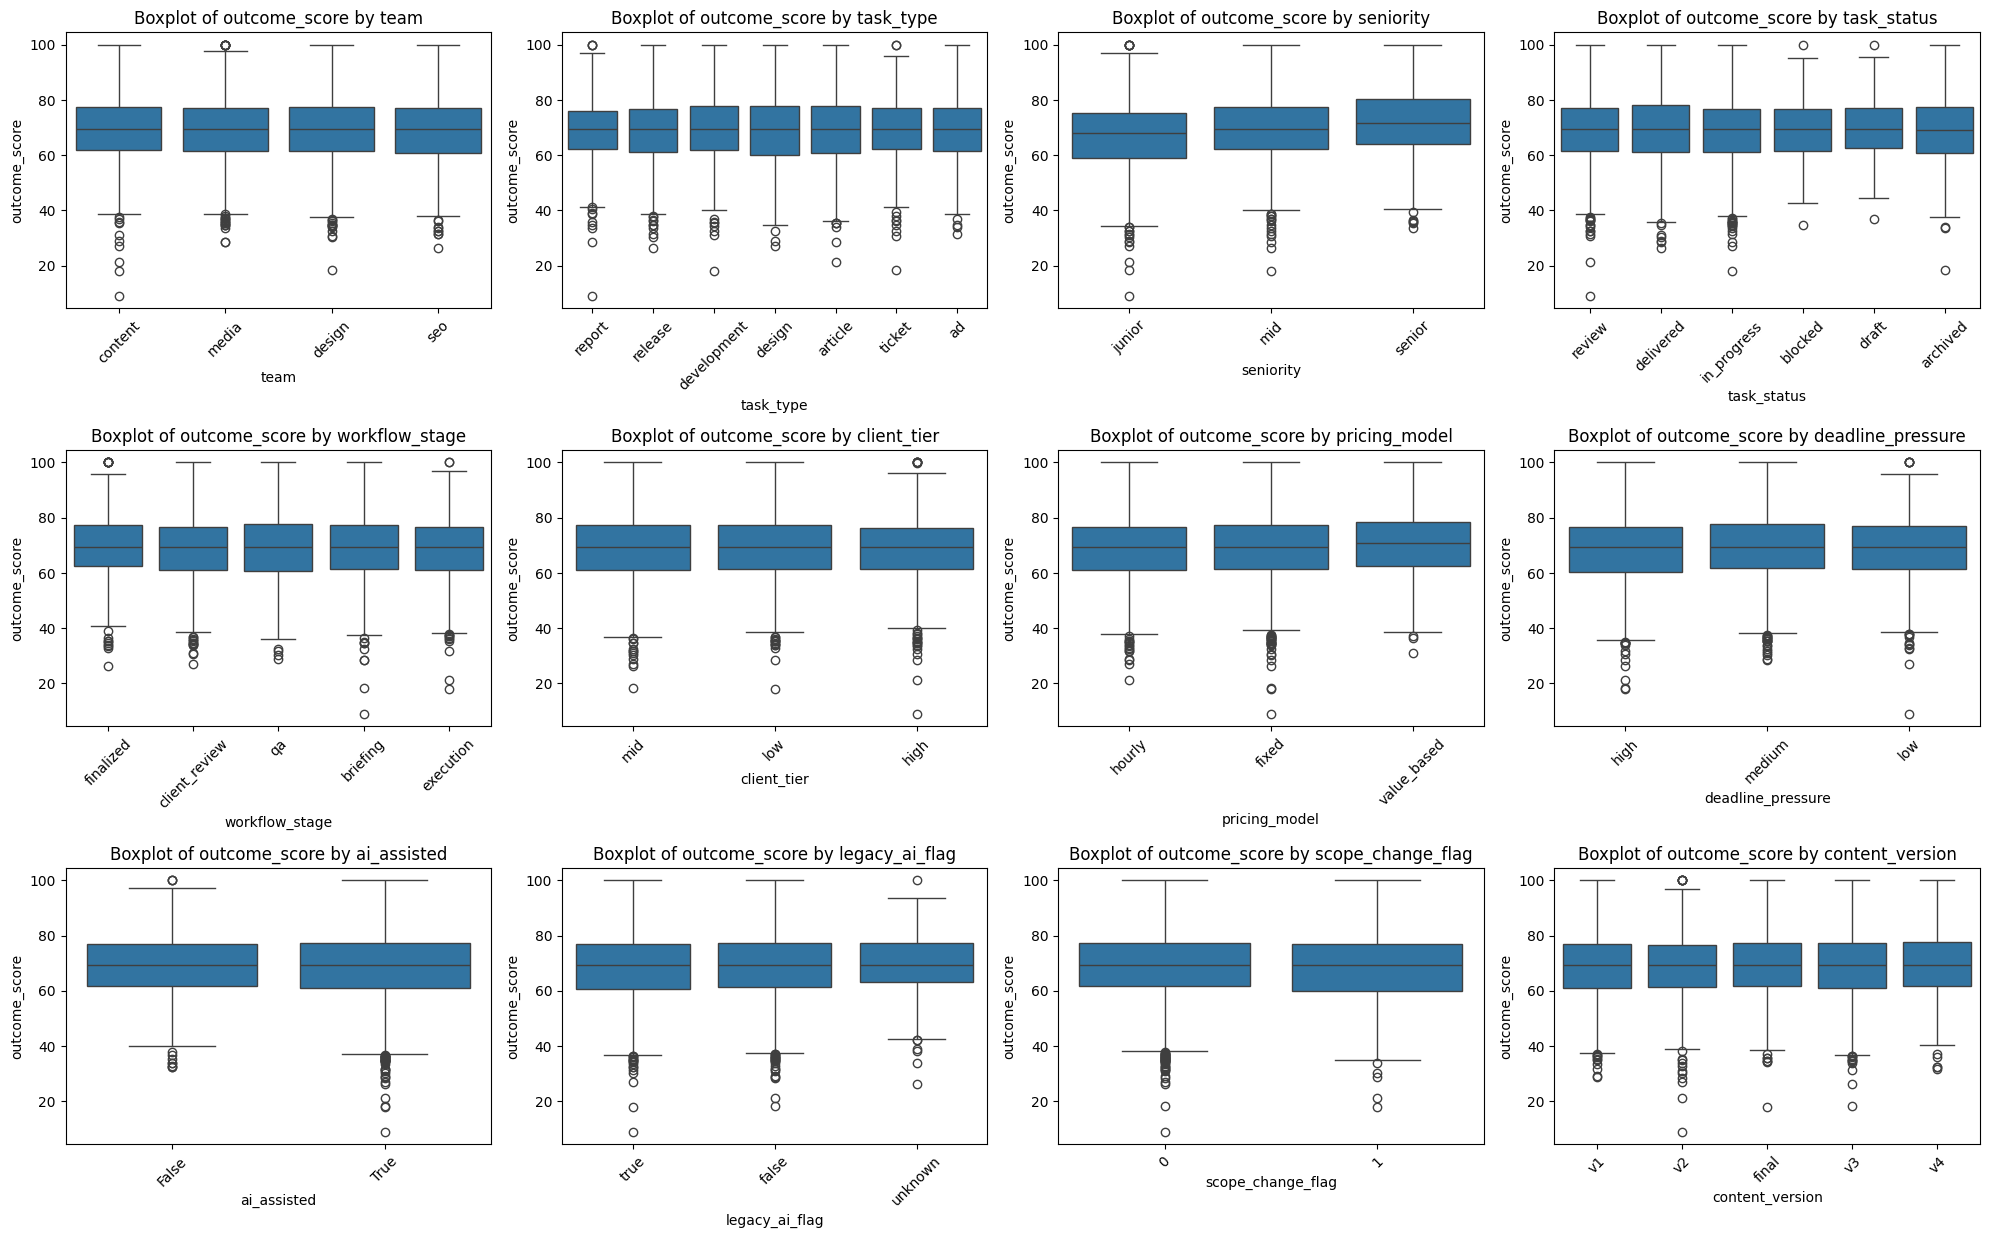

In [1602]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(cat_cols):
    plt.subplot(5, 4, i + 1)
    sns.boxplot(x=final_df[col], y=final_df["outcome_score"])
    plt.title(f"Boxplot of outcome_score by {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

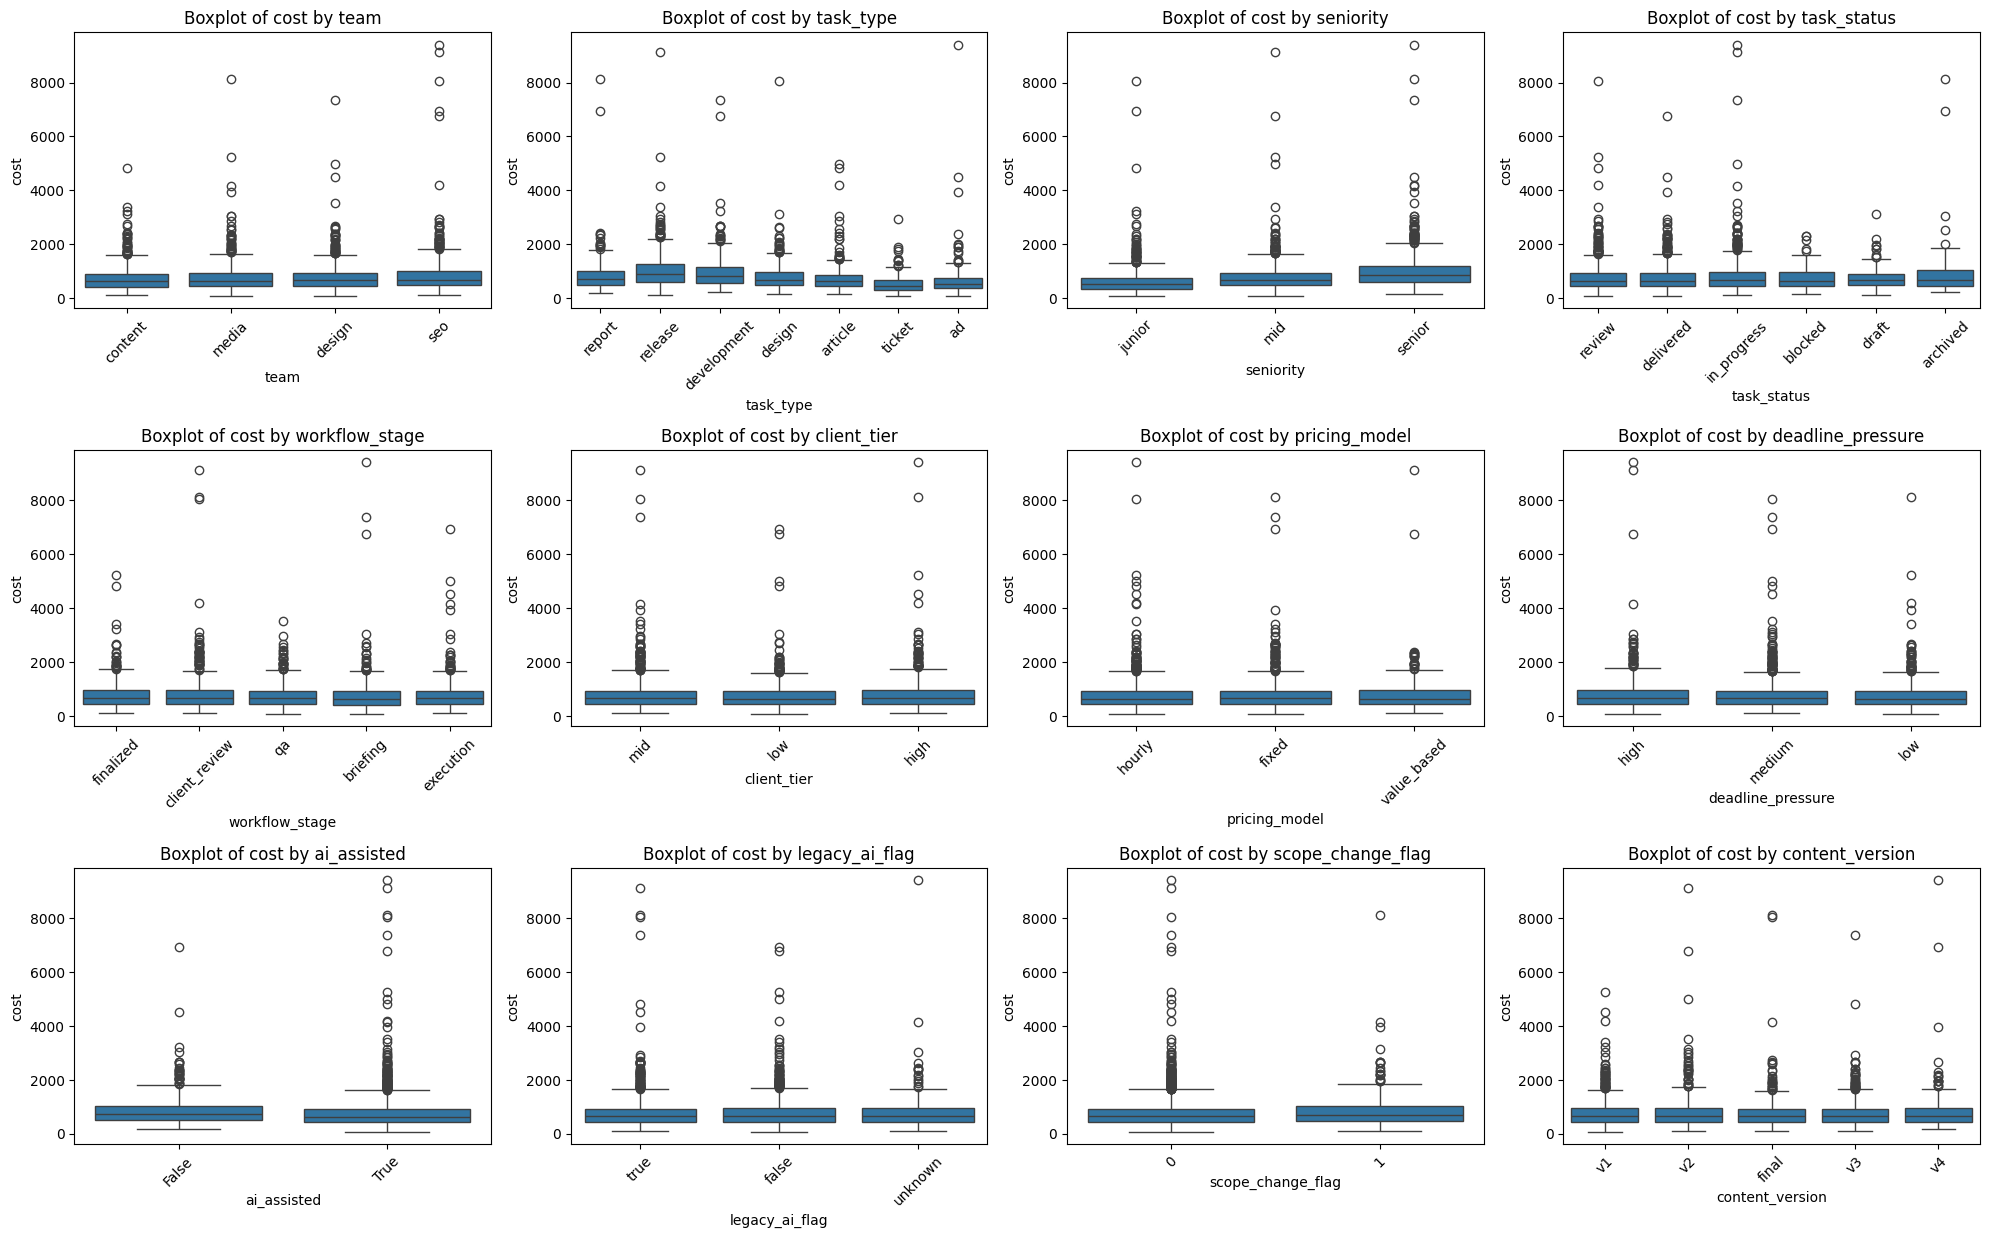

In [1603]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(cat_cols):
    plt.subplot(5, 4, i + 1)
    sns.boxplot(x=final_df[col], y=final_df["cost"])
    plt.title(f"Boxplot of cost by {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Checking inconsistencies in hours_spent, rework_hours and billable_hours

In [1604]:
# I wanna verify if there are negative values for hours_spent, billable_hours and rework_hours separately
negative_hours_spent = final_df[final_df['hours_spent'] < 0]
negative_billable_hours = final_df[final_df['billable_hours'] < 0]
negative_rework_hours = final_df[final_df['rework_hours'] < 0]

print("Negative hours_spent:", len(negative_hours_spent))
print("Negative billable_hours:", len(negative_billable_hours))
print("Negative rework_hours:", len(negative_rework_hours))

# set to 0 the negative values for billable_hours and check if everything went well
final_df.loc[final_df['billable_hours'] < 0, 'billable_hours'] = 0
print("Negative billable_hours after updating:", len(final_df[final_df['billable_hours'] < 0]))

Negative hours_spent: 0
Negative billable_hours: 17
Negative rework_hours: 0
Negative billable_hours after updating: 0


## Rework_hours vs hours_spent

A consistency check revealed 67 cases where rework_hours > hours_spent, confirming that rework_hours represent additional hours spent on corrections, separate from the original execution hours. The two variables are uncorrelated (r = 0.027, p = 0.117).

The true cost of a task is therefore hours_spent + rework_hours. Rework hours represent a hidden cost that is unlikely to be billed to the client, silently eroding the profit margin.

In [1605]:
# are rework_hours included in hours_spent or separate?
print("Cases where rework_hours > hours_spent:", 
      (final_df["rework_hours"] > final_df["hours_spent"]).sum())

corr, p = pearsonr(final_df["hours_spent"], final_df["rework_hours"])
print(f"Correlation hours_spent vs rework_hours: {corr:.4f}, p = {p:.4f}")
print(f"\nMean hours_spent: {final_df['hours_spent'].mean():.2f}")
print(f"Mean rework_hours: {final_df['rework_hours'].mean():.2f}")
print(f"Mean ratio: {(final_df['rework_hours'] / final_df['hours_spent']).mean():.4f}")

Cases where rework_hours > hours_spent: 67
Correlation hours_spent vs rework_hours: 0.0275, p = 0.1173

Mean hours_spent: 13.06
Mean rework_hours: 2.42
Mean ratio: 0.4731


### checking inconsitencies in task_complexity_score and brief_quality_score

In [1606]:
# check if there are negative values for task_complexity_score, brief_quality_score
negative_task_complexity_score = final_df[final_df['task_complexity_score'] < 0]
negative_brief_quality_score = final_df[final_df['brief_quality_score'] < 0]

print("Negative task_complexity_score:", len(negative_task_complexity_score))
print("Negative brief_quality_score:", len(negative_brief_quality_score))

Negative task_complexity_score: 0
Negative brief_quality_score: 0


## 7. Feature Engineering

We create derived variables that directly address the research questions around margin impact, quality, speed, and AI usage intensity.

### 7.1 Cost Metrics

In [1607]:
final_df["rework_ratio"] = final_df["rework_hours"] / (final_df["hours_spent"] + final_df["rework_hours"])
final_df["cost_ratio"] = final_df["cost"] / final_df["revenue"]
final_df["efficiency"] = final_df["billable_hours"] / final_df["hours_spent"]

# rework_ratio: share of total hours spent on corrections --> higher values indicate more waste
# cost_ratio: how much of each euro of revenue is absorbed by costs
# efficiency: how much time spent on a task is actually billable to the client.
# if efficiency:
    # = 1 all worked hours are billable
    # > 1 More hours are billed than actually spent. This is generally a positive outcome and may reflect high productivity.
    # < 1 Fewer hours are billed than worked. This indicates inefficiency, as some time is not generating revenue

### 7.2 Speed Metric — Delivery Time

We compute `delivery_time` as the number of calendar days between task creation and delivery. We also flag 14 anomalous rows where `delivered_at < created_at`, likely caused by swapped date entries. We also noticed that in 1448 cases `delivered_at` < `updated_at`.

In [1608]:
final_df["delivery_time"] = (final_df["delivered_at"] - final_df["created_at"]).dt.days
(final_df['delivered_at'] < final_df['created_at']).sum()
(final_df['delivered_at'] < final_df['updated_at']).sum()
col_to_see = ["task_id", "created_at", "delivered_at", "project_id", "team"]

final_df[final_df["delivered_at"] < final_df["created_at"]][col_to_see]

,task_id,created_at,delivered_at,project_id,team
89,T00089,2025-10-06,2025-10-05,P052,media
403,T00403,2026-02-09,2026-02-08,P035,seo
878,T00878,2026-03-29,2026-03-26,P035,seo
1083,T01083,2025-11-13,2025-11-12,P024,media
1112,T01112,2025-12-06,2025-12-05,P055,design
1163,T01163,2026-05-03,2026-04-30,P003,content
1169,T01169,2026-01-21,2026-01-20,P045,design
1230,T01230,2026-04-20,2026-04-17,P013,content
2127,T02127,2026-05-01,2026-04-30,P054,content
2131,T02131,2025-10-19,2025-10-16,P033,content


### Date Consistency and Delivery Time

I first check for inconsistencies between `created_at`, `updated_at`, and `delivered_at`.

A small number of cases (14) show `created_at` later than `delivered_at`, which is not logically consistent. Since these cases are very few, I assume they are due to swapped dates and correct them by switching the two columns.

On the other hand, many cases show `updated_at` later than `delivered_at`. This is expected, since `updated_at` represents the last modification of the record and can occur after delivery (e.g. for administrative updates or corrections). For this reason, no correction is applied in this case.

After fixing the inconsistencies, I compute the `delivery_time` as the difference (in days) between `delivered_at` and `created_at`.

The resulting values are all non-negative and fall within a reasonable range, confirming that the date variables are now consistent.

In [1609]:
# identify rows with swapped dates and swap them back  
neg_mask = final_df["created_at"] > final_df["delivered_at"]
print("Number of rows with created_at > delivered_at:", neg_mask.sum())  

# since only 14 times created_at > delivered_at we can assume that these are the only rows with swapped dates. We correct this.

# I need to correct the swapped dates in the created_at and delivered_at columns
final_df.loc[neg_mask, ["created_at", "delivered_at"]] = final_df.loc[neg_mask, ["delivered_at", "created_at"]].values

neg_mask2 = final_df["updated_at"] > final_df["delivered_at"]
print("Number of rows with updated_at > delivered_at:", neg_mask2.sum())
# this time 1448 rows are "swapped" between delivered_at column and updated_at one. This cannot holds.
# updated_at does not represent a specific step in the process, but rather the last time the record was modified. 
# For this reason, it can be later than delivered_at, since updates may happen after delivery (for example there can occur
# administrative changes, corrections, or billing updates).

# checking if created_at > updated_at
neg_mask3 = final_df["created_at"] > final_df["updated_at"]
print("Number of rows with created_at > updated_at:", neg_mask3.sum())

# we obtained 0 cases in which created_at column > updated_at one, so in this case there were not any kind of errors in the recordings.

# we now check if everything went well. We expect to have values different from 0 only in the neg_mask2 (updated_at > delivered_at)
neg_mask = final_df["created_at"] > final_df["delivered_at"]
neg_mask2 = final_df["updated_at"] > final_df["delivered_at"]
neg_mask3 = final_df["created_at"] > final_df["updated_at"]
print("Number of rows with created_at > delivered_at after updating:", neg_mask.sum())  
print("Number of rows with updated_at > delivered_at: after updating", neg_mask2.sum())
print("Number of rows with created_at > updated_at: after updating", neg_mask3.sum())

final_df["delivery_time"] = (final_df["delivered_at"] - final_df["created_at"]).dt.days
final_df["delivery_time"].describe()

# as we expect we did not have negative values for delivery_time. This means that date recordings are consistent.

Number of rows with created_at > delivered_at: 14
Number of rows with updated_at > delivered_at: 1445
Number of rows with created_at > updated_at: 0
Number of rows with created_at > delivered_at after updating: 0
Number of rows with updated_at > delivered_at: after updating 1445
Number of rows with created_at > updated_at: after updating 0


count    3210.000000
mean        4.495950
std         1.767619
min         0.000000
25%         3.000000
50%         5.000000
75%         6.000000
max        10.000000
Name: delivery_time, dtype: float64

In [1610]:
# handling 38 nan values previously spotted adding the mean between delivered_at - created_at
# we also update the delivery_time, previously computed

final_df['delivered_at'] = final_df['delivered_at'].fillna(final_df['created_at'] + (final_df['delivered_at'] - final_df['created_at']).mean())
final_df["delivery_time"] = (final_df["delivered_at"] - final_df["created_at"]).dt.days
#checking if there are other missingness
missing_values = final_df.isnull().sum()
print(missing_values[missing_values > 0])

jira_ticket    339
dtype: int64


### 7.3 Inconsistency: `sla_breach` vs `delivery_time`

In [1611]:
# To understand if zero correspond to tasks that were delivered in time or not
final_df["sla_breach_check"] = (final_df["delivery_time"] > final_df["sla_days"]).astype(int)
final_df[final_df["sla_breach"] != final_df["sla_breach_check"]][["task_id", "delivery_time", "sla_days", "sla_breach", "sla_breach_check"]].tail(20)   

,task_id,delivery_time,sla_days,sla_breach,sla_breach_check
895,T00895,5,5.0,1,0
939,T00939,5,5.0,1,0
1112,T01112,1,3.0,1,0
1684,T01684,4,5.0,1,0
1928,T01928,5,5.0,1,0
1944,T01944,5,5.0,1,0
2127,T02127,1,5.0,1,0
2131,T02131,3,5.0,1,0
2136,T02136,4,3.0,0,1
2184,T02184,4,5.0,1,0


In [1612]:
# with this espression: final_df["sla_breach_check"] = (final_df["delivery_time"] > final_df["sla_days"]).astype(int) 
# we have assigned zero if delivery_time was less or equal than sla_days (it's on time) 
# and 1 if delivery_time was greater than sla_days (it's late)

inconsistencies = (final_df["sla_breach"] != final_df["sla_breach_check"]).sum()
total = len(final_df)

print(f"Inconsistencies: {inconsistencies} on {total} ({inconsistencies/total*100:.1f}%)")
print("Distribution:")
print(final_df.groupby(["sla_breach", "sla_breach_check"]).size().reset_index(name="count"))

Inconsistencies: 26 on 3248 (0.8%)
Distribution:
   sla_breach  sla_breach_check  count
0           0                 0   1951
1           0                 1      4
2           1                 0     22
3           1                 1   1271


In [1613]:
# A consistency check between the original 'sla_breach' variable and a recomputed version based on delivery_time > sla_days revealed more than 5% inconsistencies,
# meaning the original variable cannot be considered reliable.
# Our decision: 'sla_breach' has been fully replaced with the recomputed version,
# where:
#   1 = delivery_time > sla_days  (task delivered late — breach)
#   0 = delivery_time <= sla_days (task delivered on time — no breach)

final_df["sla_breach"] = final_df["sla_breach_check"]
final_df.drop(columns=["sla_breach_check"], inplace=True)

### 7.4 AI Complexity Interaction and Error & Revision Rates

In [1614]:
final_df["ai_complexity"] = final_df["task_complexity_score"] * final_df["ai_usage_pct"]

# Task complexity is measured on a discrete scale from 1 to 5. This new column is a proxy to see whether the effectiveness of AI varies across different levels of complexity.

In [1615]:
final_df["error_rate"] = final_df["errors"] / final_df["hours_spent"]
final_df["revisions_rate"] = final_df["revisions"] / final_df["hours_spent"]

### 7.5 AI_Group

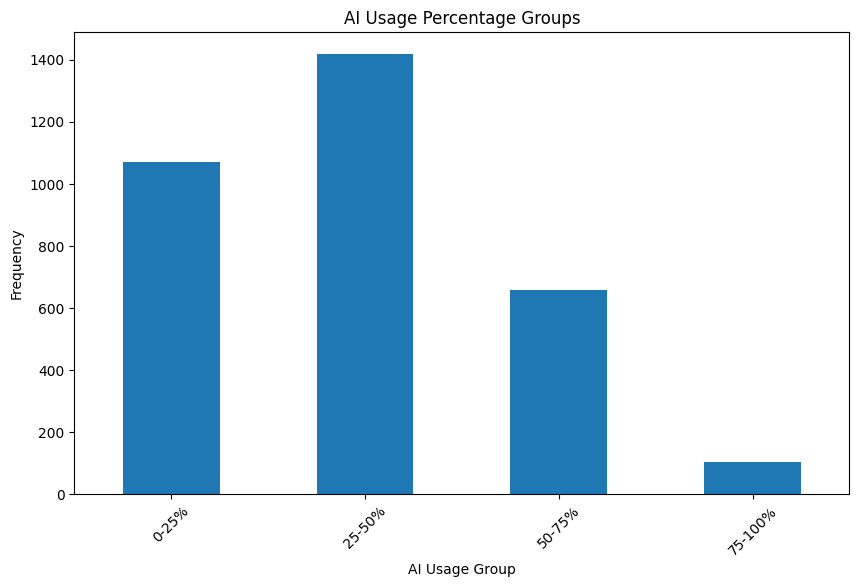

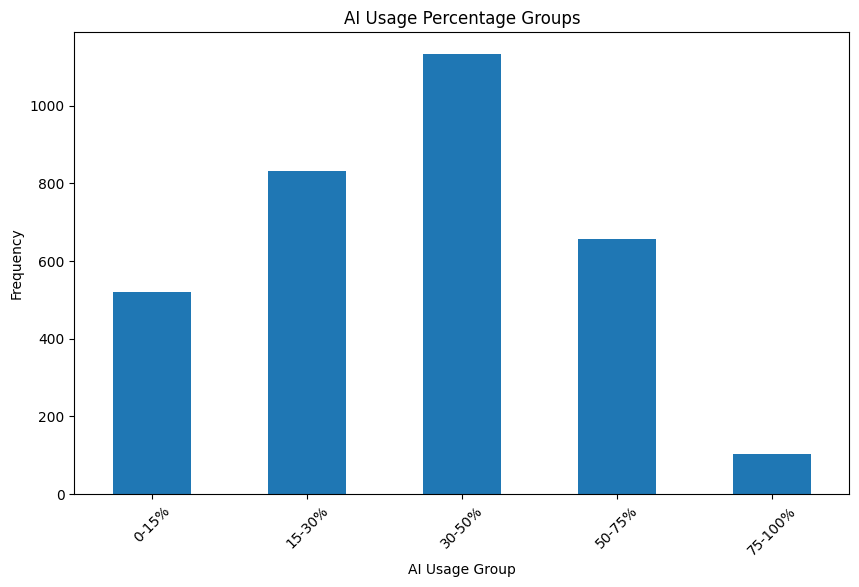

In [1616]:
#bins on ai usage_pct: 0-25% / 25-50% / 50-75% / 75-100% calling them ai_group
final_df["ai_group"] = pd.cut(final_df["ai_usage_pct"], bins=[-1, 0.25, 0.5, 0.75, 1], labels=["0-25%", "25-50%", "50-75%", "75-100%"])
final_df["ai_group"].value_counts().sort_index()
plt.figure(figsize=(10, 6))
final_df["ai_group"].value_counts().sort_index().plot(kind="bar")
plt.title("AI Usage Percentage Groups")
plt.xlabel("AI Usage Group")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

# we redefine ai_group with new bins, since they capture more nuances (the 25-50% range is too concentrated)
final_df["ai_group"] = pd.cut(final_df["ai_usage_pct"], bins=[-1, 0.15, 0.3, 0.5, 0.75, 1], labels=["0-15%", "15-30%", "30-50%", "50-75%", "75-100%"])
final_df["ai_group"].value_counts().sort_index()

# visualize ai_group distribution of the new bins
plt.figure(figsize=(10, 6))
final_df["ai_group"].value_counts().sort_index().plot(kind="bar")
plt.title("AI Usage Percentage Groups")
plt.xlabel("AI Usage Group")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

### 7.6 Inconsistency: `ai_assisted = False` but `ai_usage_pct > 0`



685 rows have ai_assisted = False despite a positive ai_usage_pct.
We found that 519 cases fall within the 0–15% usage bucket, suggesting low-level AI involvement that was not formally flagged as assisted.
An additional 136 cases fall within the 15–30% range, indicating that most inconsistencies are still concentrated at relatively low levels of AI usage. Only 30 cases exceed 30%, and none are observed above 50%.


**Resolution strategy:** we compute the median `ai_usage_pct` among these inconsistent rows and use it as a threshold. Tasks above the threshold are reclassified as `ai_assisted = True`; tasks at or below it are treated as genuinely non-assisted and their `ai_usage_pct` is set to 0.

In [1617]:
# inspect ai_usage_pct distribution for inconsistent rows (ai_assisted=False but ai_usage_pct > 0)  
# gestire il problema ai usage / ai assisted
inconsistent_mask = (final_df["ai_assisted"] == False) & (final_df["ai_usage_pct"] > 0)  
print("Inconsistent rows:", inconsistent_mask.sum())  
print()  
print(final_df[inconsistent_mask]["ai_usage_pct"].describe())  
print()  
print("Distribution across ai_group:")  
print(final_df[inconsistent_mask]["ai_group"].value_counts())

Inconsistent rows: 685

count    685.000000
mean       0.118409
std        0.065219
min        0.010000
25%        0.070000
50%        0.120000
75%        0.150000
max        0.340000
Name: ai_usage_pct, dtype: float64

Distribution across ai_group:
ai_group
0-15%      519
15-30%     136
30-50%      30
50-75%       0
75-100%      0
Name: count, dtype: int64


In [1618]:
 # we use the median of ai_usage_pct among these rows as the threshold  

threshold = final_df[inconsistent_mask]["ai_usage_pct"].median()  
print(f"Threshold: {threshold:.3f}")  

# rows above threshold: reclassify as ai_assisted = True  
above_threshold = inconsistent_mask & (final_df["ai_usage_pct"] > threshold)  
final_df.loc[above_threshold, "ai_assisted"] = True  

# rows at or below threshold: set ai_usage_pct = 0 (treat as non-assisted)  
below_threshold = inconsistent_mask & (final_df["ai_usage_pct"] <= threshold)  
final_df.loc[below_threshold, "ai_usage_pct"] = 0  

# verify: no inconsistent rows should remain  
remaining = (final_df["ai_assisted"] == False) & (final_df["ai_usage_pct"] > 0)  
print(f"Remaining inconsistencies: {remaining.sum()}")  
print()  
print("Updated ai_assisted distribution:")  
print(final_df["ai_assisted"].value_counts())  

Threshold: 0.120
Remaining inconsistencies: 0

Updated ai_assisted distribution:
ai_assisted
True     2864
False     384
Name: count, dtype: int64


### 7.7 Margin & Profitability Variables

These features directly address the reaserch question 1 (margin impact of AI) and reaserch question 5 (threshold detection).  
`profit_margin` normalises profit by revenue, making tasks of different sizes comparable.  
`is_loss` is a binary flag to isolate tasks where the firm lost money.

In [1619]:
# profit margin as a share of revenue  
final_df["profit_margin"] = (final_df["profit"] / final_df["revenue"])
final_df["profit_per_hour"] = final_df["profit"] / final_df["hours_spent"]
final_df["revenue_per_hour"] = final_df["revenue"] / final_df["hours_spent"]

# binary flag: did this task generate a loss?  
final_df["is_loss"] = (final_df["profit"] < 0).astype(int)  
final_df[["profit", "profit_margin", "profit_per_hour", "revenue_per_hour", "is_loss"]].describe()  

,profit,profit_margin,profit_per_hour,revenue_per_hour,is_loss
count,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000
mean,349.263114,0.148953,99.889272,221.567557,0.251539
std,888.072715,0.764017,2219.490372,2956.067534,0.433965
min,-8510.549511,-16.736802,-26539.473176,3.737055,0.000000
25%,-2.610000,-0.004855,-0.266774,61.570059,0.000000
50%,254.645000,0.290493,23.375599,81.430198,0.000000
75%,590.400000,0.513023,53.291196,109.538765,1.000000
max,14006.644324,0.962587,102291.000000,127177.500000,1.000000


## Question 1

### Profitability for AI group

`profit_margin` increases monotonically with AI usage intensity.

The 75-100% group shows the highest median profit margin and the least extreme downside outliers, suggesting that high AI adoption is associated with both  better average performance and lower tail risk.

The 15-30% group presents the most volatile outcomes, with the largest negative  outliers (down to -17x). This may indicate tasks where AI was partially adopted  but not effectively integrated.

In [1620]:
# computing the mean, median, min and max of profit for each ai_group
final_df.groupby("ai_group")["profit"].agg(["count", "mean", "median", "min", "max"]).sort_values("mean")

,count,mean,median,min,max
ai_group,,,,,
0-15%,521,244.451065,185.950,-1714.660000,3998.540000
15-30%,833,262.008333,200.900,-8510.549511,14006.644324
30-50%,1133,376.974959,261.820,-6634.868294,8601.084294
50-75%,658,449.322979,336.295,-2027.255027,7421.689392
75-100%,103,641.043690,414.880,-3714.482162,6483.178762


/var/folders/64/3w707y752n76rvfcs7n14qk80000gn/T/ipykernel_99885/3659717342.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_df, x="ai_group", y="profit_margin", order=["0-15%","15-30%","30-50%","50-75%","75-100%"], palette="Blues")


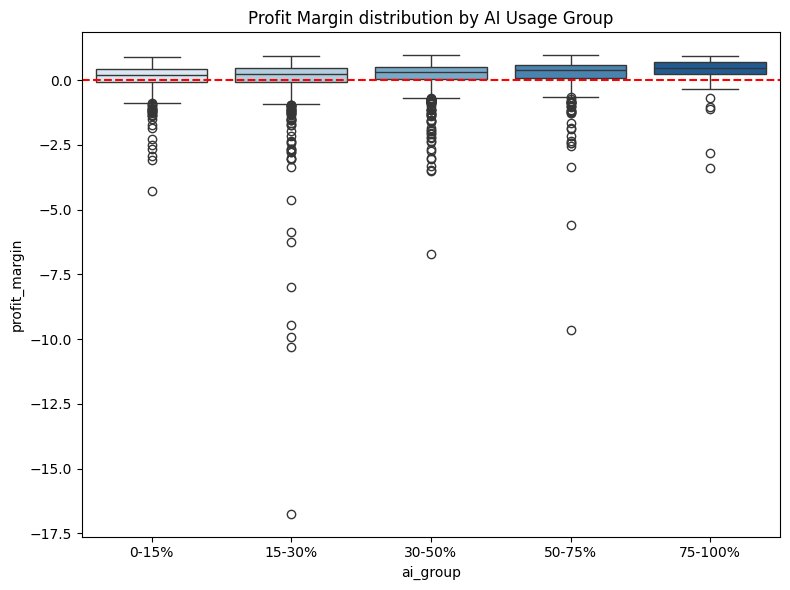

In [1621]:
#Distribution of profit_margin for ai_group (boxplot)
plt.figure(figsize=(8, 6))
sns.boxplot(data=final_df, x="ai_group", y="profit_margin", order=["0-15%","15-30%","30-50%","50-75%","75-100%"], palette="Blues")
plt.axhline(0, color="red", linestyle="--")
plt.title("Profit Margin distribution by AI Usage Group")
plt.tight_layout()
plt.show()

In [1622]:
#profit_per_hour and revenue_per_hour for ai_group. 
summary = final_df.groupby("ai_group", observed=True).agg(
    mean_profit_margin=("profit_margin", "mean"),
    mean_profit_per_hour=("profit_per_hour", "mean"),
    mean_revenue_per_hour=("revenue_per_hour", "mean"),
    loss_rate=("is_loss", "mean"),
    n=("profit_margin", "count")
).reset_index()
print(summary)

  ai_group  mean_profit_margin  mean_profit_per_hour  mean_revenue_per_hour  \
0    0-15%            0.094599             52.937324             155.652245   
1   15-30%            0.025343             41.861942             148.860064   
2   30-50%            0.196759            190.163885             354.632250   
3   50-75%            0.236360             59.114883             150.518099   
4  75-100%            0.339304             74.133380             133.174029   

   loss_rate     n  
0   0.303263   521  
1   0.300120   833  
2   0.231244  1133  
3   0.205167   658  
4   0.116505   103  


(Results based on median `profit_margin` to ensure robustness against the extreme 
negative outliers observed in the distribution, particularly in the 15–30% group.)

Median `profit_margin` increases monotonically from 0.22 (0–15% AI) to 0.48 (75–100% AI),
more than doubling across the spectrum. Loss rate drops from ~30% in low-usage groups 
to 11.6% at high usage, suggesting that intensive AI adoption reduces both average costs 
and downside risk.

The 15–30% group is the most dangerous: despite a median similar to the 0–15% group,
its mean collapses to 0.025 due to extreme negative outliers. This "partial adoption" 
scenario, where AI is introduced but not fully integrated, appears to generate 
the highest tail risk.

In [1623]:
#Since extreme outliers distort boxplots, I add this cell to see clean medians
final_df.groupby("ai_group", observed=True).agg(
    median_profit_margin=("profit_margin", "median"),
    mean_profit_margin=("profit_margin", "mean"),
    loss_rate=("is_loss", "mean"),
    n=("profit_margin", "count")
).reset_index()

,ai_group,median_profit_margin,mean_profit_margin,loss_rate,n
0,0-15%,0.216776,0.094599,0.303263,521
1,15-30%,0.228688,0.025343,0.300120,833
2,30-50%,0.303398,0.196759,0.231244,1133
3,50-75%,0.378332,0.236360,0.205167,658
4,75-100%,0.475565,0.339304,0.116505,103


### Where does AI create the most value? By task type and team

By `task type`: AI delivers the strongest margin improvement in design (+0.44 from 
low to high usage), report (+0.45) and ticket (+0.54 at 75-100%). 
Release tasks show the most extreme reversal: a mean margin of -0.29 at partial 
adoption (15-30%) flips to +0.45 at full adoption, the largest swing in the matrix.
The only exception is article, where high AI usage (75-100%) is associated with 
a negative margin (-0.15), suggesting that AI-generated content may incur higher 
revision or quality costs in text-heavy deliverables.

By `team`: all teams benefit from higher AI usage, but the magnitude differs.
The media team shows the earliest gains (already strong at 50-75%), while the 
seo team has the highest upside potential — near-zero margins at low usage 
growing to 0.39 at maximum intensity. The partial adoption trap (15-30%) 
reappears in the design team (-0.09), consistent with the overall pattern.

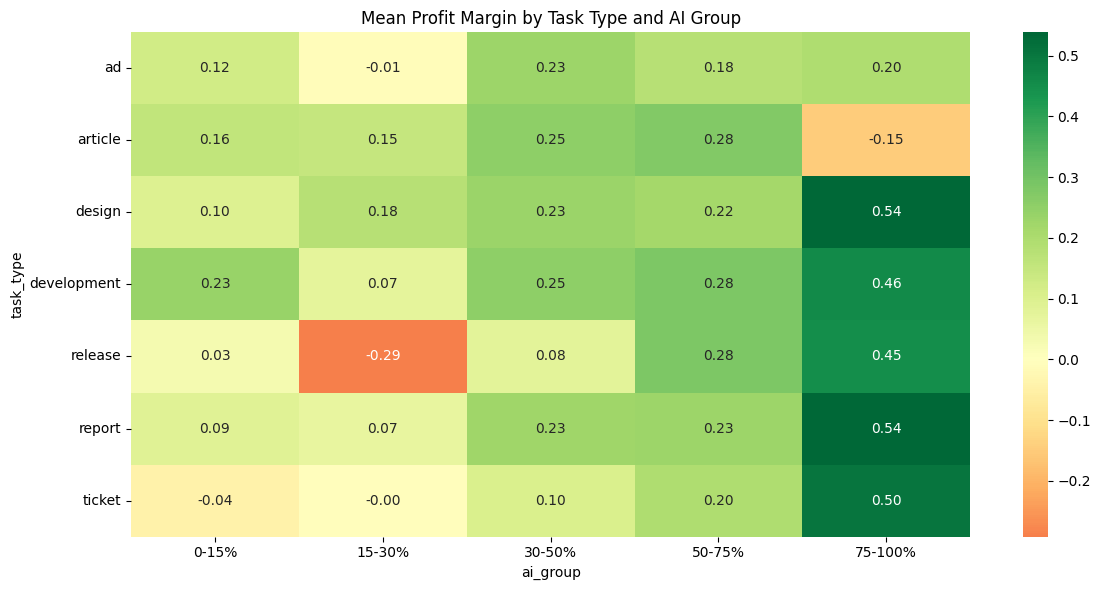

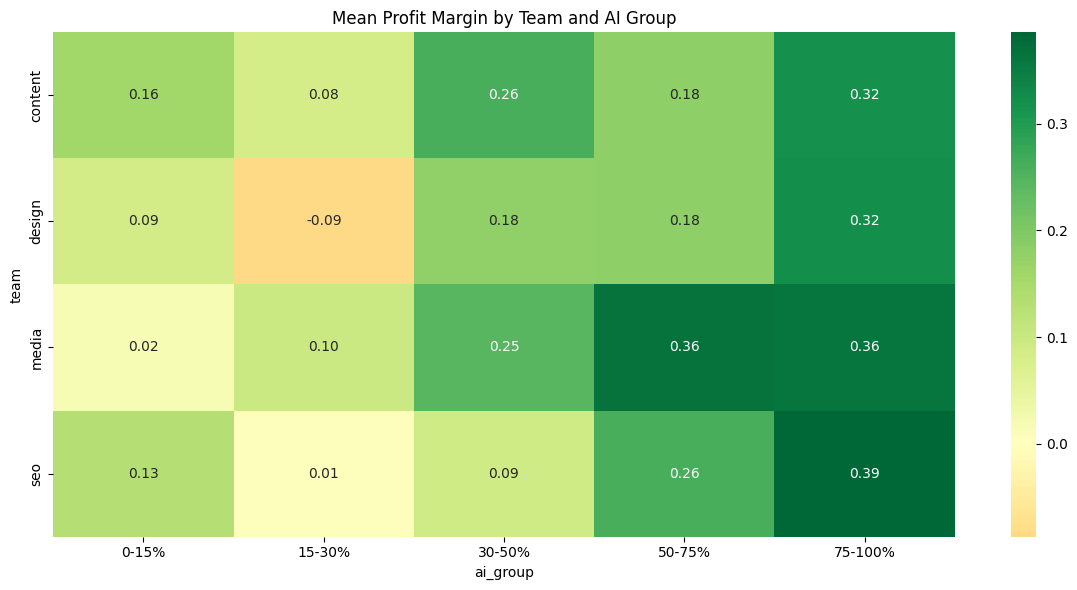

In [1624]:
# average profit_margin for task_type and ai_group (heatmap)
pivot = final_df.groupby(["task_type", "ai_group"], observed=True)["profit_margin"].mean().unstack()
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title("Mean Profit Margin by Task Type and AI Group")
plt.tight_layout()
plt.show()

# the same for team
pivot_team = final_df.groupby(["team", "ai_group"], observed=True)["profit_margin"].mean().unstack()
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_team, annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title("Mean Profit Margin by Team and AI Group")
plt.tight_layout()
plt.show()

### AI e qualità: outcome_score e rework_ratio per ai_group

AI and quality: outcome_score, rework_ratio, error_rate, revisions_rate:

`outcome_score` remains stable across all AI usage groups (median ~68-70), 
with no meaningful improvement even at high AI intensity. Notably, the 75-100% 
group shows a slightly lower median, suggesting that maximum AI adoption 
does not translate into better perceived output quality.

However, AI shows the highest value for `rework_ratio`, suggesting that, generally, using AI increases the rework hours committed to a work.  
`error_rate` and `revisions_rate` all show their most extreme outliers concentrated 
in the 30-50% group, while the 75-100% group consistently has the fewest 
and least severe cases.

Key implication: AI does not create value through quality improvement 
but through operational efficiency, reducing the incidence of extreme 
rework and error events. The margin gains observed before are therefore 
more likely driven by cost reduction than by superior deliverable quality.

/var/folders/64/3w707y752n76rvfcs7n14qk80000gn/T/ipykernel_99885/703833617.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_df, x="ai_group", y="outcome_score",
/var/folders/64/3w707y752n76rvfcs7n14qk80000gn/T/ipykernel_99885/703833617.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_df, x="ai_group", y="rework_ratio",


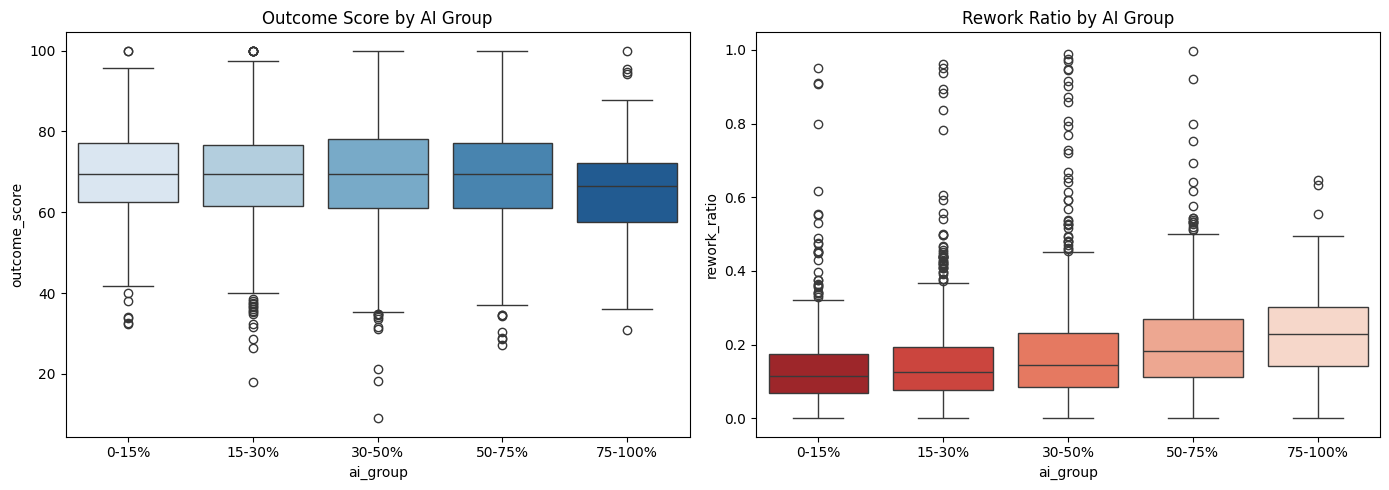

In [1625]:
# outcome_score and rework_ratio by ai_group
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=final_df, x="ai_group", y="outcome_score",
            order=["0-15%","15-30%","30-50%","50-75%","75-100%"], palette="Blues", ax=axes[0])
axes[0].set_title("Outcome Score by AI Group")

sns.boxplot(data=final_df, x="ai_group", y="rework_ratio",
            order=["0-15%","15-30%","30-50%","50-75%","75-100%"], palette="Reds_r", ax=axes[1])
axes[1].set_title("Rework Ratio by AI Group")

plt.tight_layout()
plt.show()

# error_rate  and revisions_rate by ai_group
#fig, axes = plt.subplots(1, 2, figsize=(14, 5))
#sns.boxplot(data=final_df, x="ai_group", y="error_rate",
            #order=["0-15%","15-30%","30-50%","50-75%","75-100%"], palette="Oranges", ax=axes[0])
#axes[0].set_title("Error Rate by AI Group")

#sns.boxplot(data=final_df, x="ai_group", y="revisions_rate",
            #order=["0-15%","15-30%","30-50%","50-75%","75-100%"], palette="Oranges", ax=axes[1])
#axes[1].set_title("Revisions Rate by AI Group")
#plt.tight_layout()
#plt.show()

### AI and Speed: SLA Breach and Delivery Time for AI Group

`sla_breach` rate ranges narrowly between 55% and 59% across all AI usage groups, with no meaningful difference attributable to AI intensity.
`delivery_time` similarly shows no systematic improvement, with median consistently around 6 days across all groups.

Conclusion: AI has no measurable impact on delivery speed. Combined with Block C findings, this further confirms that AI value creation operates exclusively through cost reduction, not through speed or quality improvements.

/var/folders/64/3w707y752n76rvfcs7n14qk80000gn/T/ipykernel_99885/774237410.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=breach_by_ai, x="ai_group", y="sla_breach", palette="Blues_d")


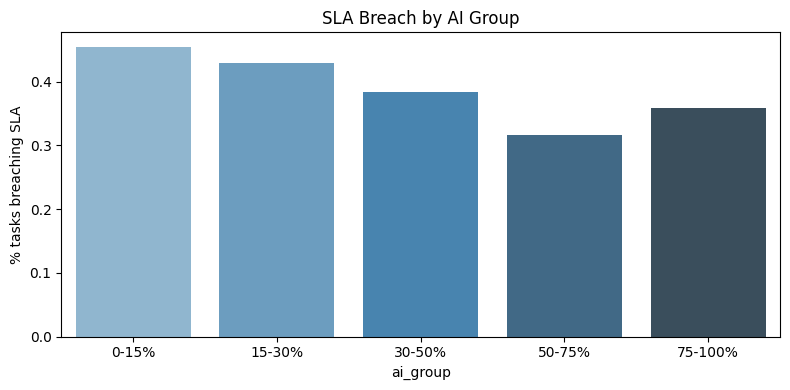

/var/folders/64/3w707y752n76rvfcs7n14qk80000gn/T/ipykernel_99885/774237410.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_df, x="ai_group", y="delivery_time",


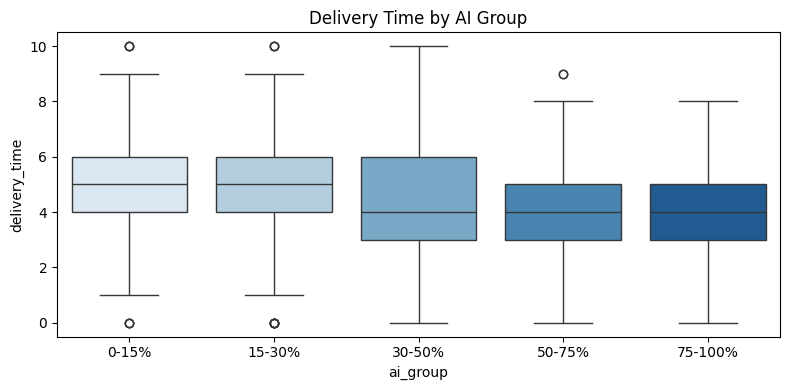

In [1626]:
# SLA breach by ai_group
breach_by_ai = final_df.groupby("ai_group", observed=True)["sla_breach"].mean().reset_index()
plt.figure(figsize=(8, 4))
sns.barplot(data=breach_by_ai, x="ai_group", y="sla_breach", palette="Blues_d")
plt.title("SLA Breach by AI Group")
plt.ylabel("% tasks breaching SLA")
plt.tight_layout()
plt.show()

# delivery_time by ai_group
plt.figure(figsize=(8, 4))
sns.boxplot(data=final_df, x="ai_group", y="delivery_time",
            order=["0-15%","15-30%","30-50%","50-75%","75-100%"], palette="Blues")
plt.title("Delivery Time by AI Group")
plt.tight_layout()
plt.show()

### Statistical tests to validate the differences

Why two tests?
The two tests answer complementary questions:

- **Kruskal-Wallis** asks: "Are the distributions of profit_margin 
  statistically different across the five ai_group buckets?"
- **Linear Regression** asks: "Is there a significant linear relationship 
  between ai_usage_pct (continuous) and profit_margin, and how strong is it?"

Using both provides a more robust validation: one tests differences between 
discrete groups, the other captures the continuous relationship.

Kruskal-Wallis is a non-parametric test, meaning it does not assume that 
the data follows a normal distribution.


The test works in four steps:

1. **Rank transformation**: all values across all groups are pooled together 
   and ranked from smallest to largest. This makes the test robust to outliers 
   — a value of -17 and a value of -10 both contribute as "low ranks" without 
   the extreme value dominating the calculation.

2. **Mean rank per group**: the average rank is computed for each ai_group. 
   If all groups were identical, each group's mean rank would be close to 
   the global mean rank.

3. **H statistic**: measures how much the group mean ranks deviate from the 
   global mean rank. The larger H, the more the groups differ from each other.

4. **P-value**: H follows a chi-square distribution. The p-value answers: 
   "If all groups were truly equal, what is the probability of observing 
   an H this large by chance?"
   - p < 0.05 → differences are statistically significant
   - p ≥ 0.05 → differences could be due to chance


One important limitation: Kruskal-Wallis only tells us that *at least one 
group is different*, not which specific pairs differ. In this analysis, 
the direction and magnitude of differences are already visible from the 
boxplots and heatmaps that we saw before, so no post-hoc test is needed.

Three complementary tests confirm that the relationship between AI usage 
and profit_margin is statistically significant:

- Kruskal-Wallis (p < 0.0001): differences across ai_group buckets are 
  not due to chance
- Pearson correlation (r = 0.106, p < 0.0001): a positive linear 
  relationship exists between ai_usage_pct and profit_margin
- Linear regression (coef = 0.387, R² = 0.011): each 1-unit increase 
  in ai_usage_pct is associated with a +0.39 increase in profit_margin

However, the low R² (1.1%) indicates that ai_usage_pct alone explains 
very little of the variance in profit_margin. The effect of AI on margin 
is real but context-dependent — task_type and team are critical moderators, 
as shown before

In [1627]:
from scipy.stats import kruskal

metrics = ["profit_margin", "outcome_score", "rework_ratio", "error_rate", "delivery_time", "sla_breach"]

print("Kruskal-Wallis test — differenze tra ai_group:\n")
for metric in metrics:
    groups = [final_df[final_df["ai_group"] == g][metric].dropna()
              for g in ["0-15%","15-30%","30-50%","50-75%","75-100%"]]
    stat, p = kruskal(*groups)
    sig = "✓ significativo" if p < 0.05 else "✗ non significativo"
    print(f"  {metric}: p = {p:.4f}  {sig}")

Kruskal-Wallis test — differenze tra ai_group:

  profit_margin: p = 0.0000  ✓ significativo
  outcome_score: p = 0.0348  ✓ significativo
  rework_ratio: p = 0.0000  ✓ significativo
  error_rate: p = 0.0001  ✓ significativo
  delivery_time: p = 0.0000  ✓ significativo
  sla_breach: p = 0.0000  ✓ significativo


In [1628]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = final_df["ai_usage_pct"].values.reshape(-1, 1)
y = final_df["profit_margin"].values

model = LinearRegression()
model.fit(X, y)

print(f"Coefficiente: {model.coef_[0]:.4f}")
print(f"Intercetta: {model.intercept_:.4f}")
print(f"R²: {model.score(X, y):.4f}")

Coefficiente: 0.3873
Intercetta: 0.0127
R²: 0.0112


In [1629]:
from scipy.stats import pearsonr

corr, p = pearsonr(final_df["ai_usage_pct"], final_df["profit_margin"])
print(f"Correlazione: {corr:.4f}")
print(f"P-value: {p:.4f}")

Correlazione: 0.1058
P-value: 0.0000


### Scatter ai_usage_pct vs profit_margin with regression
The left plot confirms that higher AI usage is associated with slightly 
higher profit margins, but the relationship is weak. The most visible 
pattern is that the largest losses (down to -17) are almost entirely 
concentrated where AI usage is lowest, while high AI usage tasks cluster 
near zero and positive values.

The right plot shows a flat regression line across all AI usage levels, 
confirming that AI has no impact on output quality regardless of how 
much it is used.

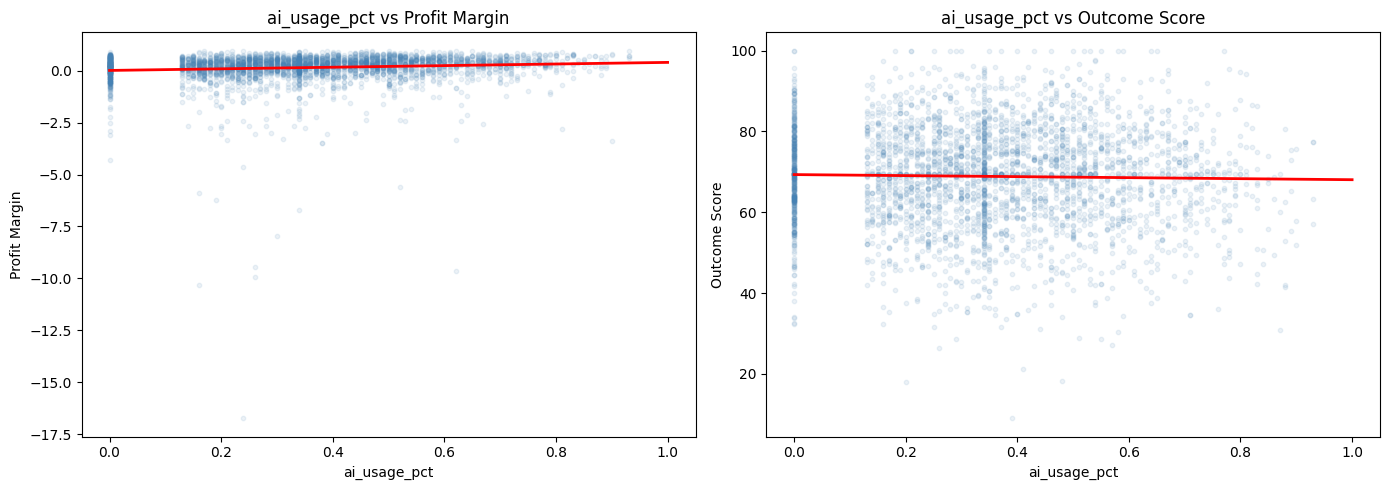

In [1630]:
# Scatter con trend line — showing the relationship continuosly not by buckets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, label in zip(axes,
                              ["profit_margin", "outcome_score"],
                              ["Profit Margin", "Outcome Score"]):
    ax.scatter(final_df["ai_usage_pct"], final_df[metric], alpha=0.1, s=10, color="steelblue")
    m, b = np.polyfit(final_df["ai_usage_pct"].dropna(), final_df[metric].dropna(), 1)
    x = np.linspace(0, 1, 100)
    ax.plot(x, m*x + b, color="red", linewidth=2)
    ax.set_xlabel("ai_usage_pct")
    ax.set_ylabel(label)
    ax.set_title(f"ai_usage_pct vs {label}")

plt.tight_layout()
plt.show()

## RQ1 — Where is value created?

AI creates value primarily through margin improvement and loss reduction.

Median profit margin more than doubles from 0.22 (0–15% AI) to 0.48 
(75–100% AI), while loss rate drops from ~30% to 11.6% — making a 
loss-making task nearly 3x less likely at high AI intensity.

The effect is strongest in design, report and ticket tasks, and in 
the media and seo teams.

Value is not created through quality (outcome_score is flat across 
all groups) or speed (sla_breach stable at 55–59%). AI works exclusively 
by reducing extreme rework and error events.

One key risk: the 15–30% usage group shows the highest tail risk, 
suggesting that partial AI adoption is worse than no adoption at all.

## Question 2

### Loss profile by category

Loss rate by category:

By `task_type` ticket (35%) and release (31%) show the highest loss rates,
while article (19%) and design (21%) are the safest. By `team`, loss rates 
are uniformly distributed between 22% and 27%, with no team standing out 
as structurally more problematic.

The most striking finding is by `seniority`: senior staff show the highest 
loss rate (45%), followed by mid (26%) and junior (11%). This counter-intuitive 
result likely reflects task allocation — senior employees are assigned 
more complex and higher-risk tasks, and their higher hourly cost makes 
the same task more likely to generate a loss.

By `client_tier`, low-tier clients show the highest loss rate (30%) versus 
21% for high-tier clients, consistent with the expectation that premium 
clients have better-structured contracts and protected margins.

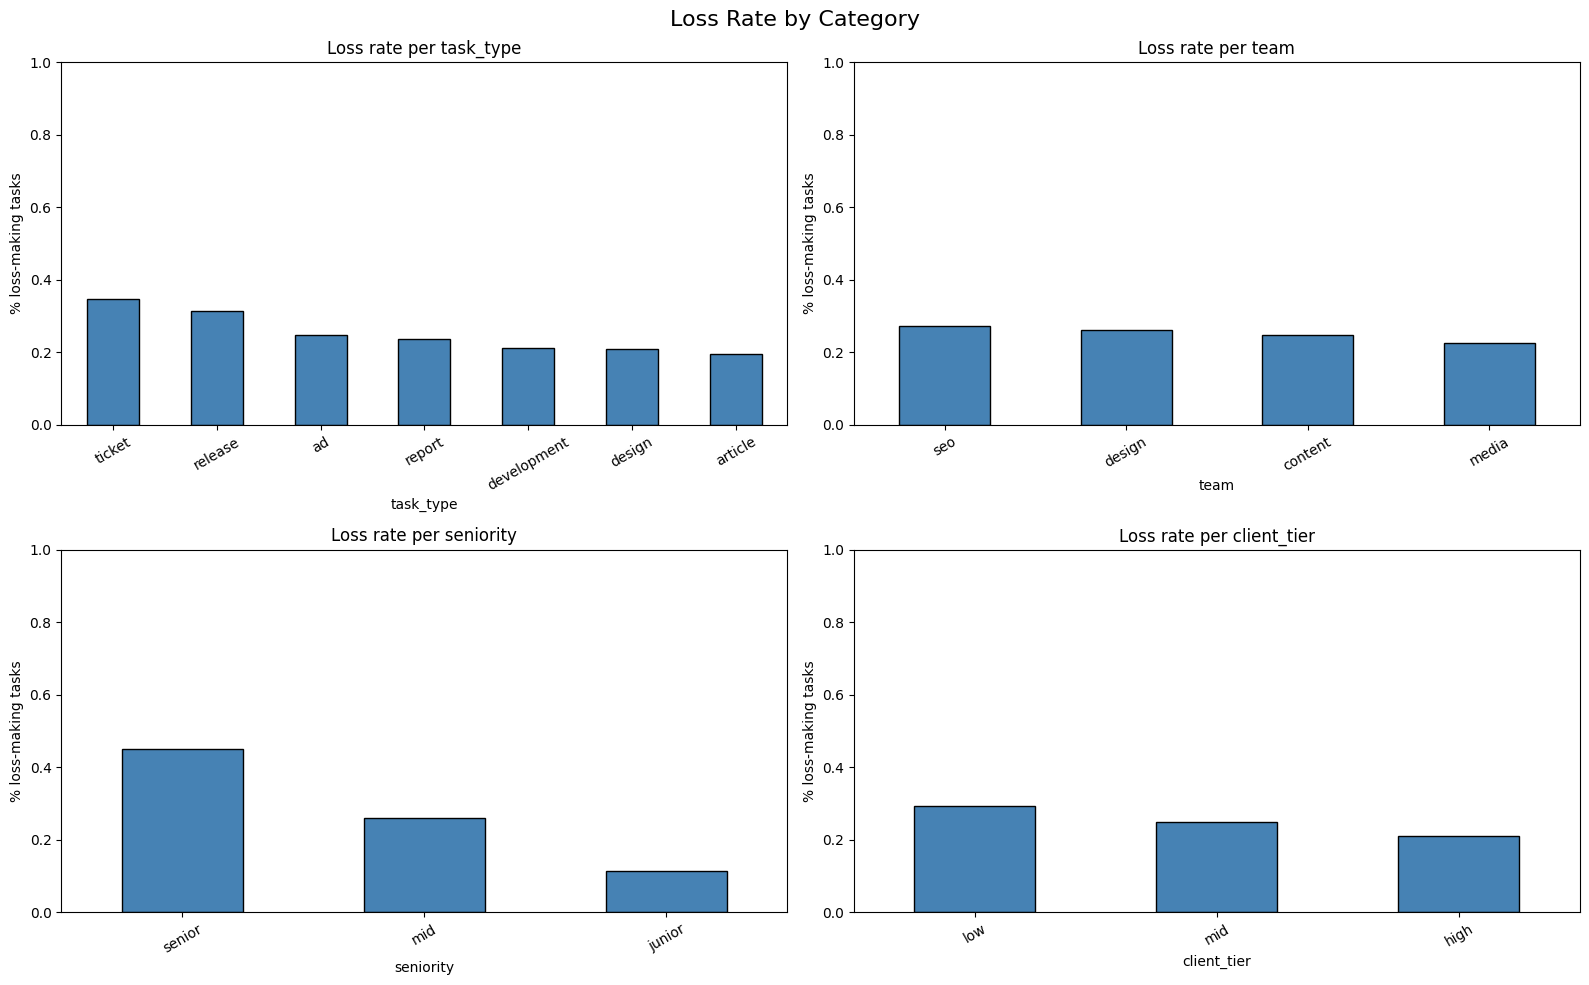

In [1631]:
# loss rate per task_type, team, seniority, client_tier
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, col in zip(axes.flatten(), ["task_type", "team", "seniority", "client_tier"]):
    loss_rate = final_df.groupby(col)["is_loss"].mean().sort_values(ascending=False)
    loss_rate.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(f"Loss rate per {col}")
    ax.set_ylabel("% loss-making tasks")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Loss Rate by Category", fontsize=16)
plt.tight_layout()
plt.show()

### Rework, errors, and hidden costs
Rework, errors and hidden costs — loss vs no loss:

`rework_ratio` and `error_rate` show almost identical distributions between 
loss and no-loss tasks, with extreme outliers present in both groups. 
This rules out rework and errors as primary drivers of losses.

The key driver is `cost_ratio`: loss-making tasks show a median cost_ratio 
of ~1.8 (costs exceed revenue by 80%), compared to ~0.7 for profitable tasks. 
The wide IQR and extreme outliers (up to 17.5x) in the loss group indicate 
that losses are not caused by operational inefficiency (rework, errors) 
but by a structural cost-revenue imbalance — likely driven by underpricing 
or cost underestimation at the task level.

/var/folders/64/3w707y752n76rvfcs7n14qk80000gn/T/ipykernel_99885/2434236334.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_df, x="is_loss", y=col, ax=ax, palette=["steelblue", "tomato"])
/var/folders/64/3w707y752n76rvfcs7n14qk80000gn/T/ipykernel_99885/2434236334.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No loss", "Loss"])
/var/folders/64/3w707y752n76rvfcs7n14qk80000gn/T/ipykernel_99885/2434236334.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_df, x="is_loss", y=col, ax=ax, palette=["steelblue", "tomato"])
/var/folders/64/3w707y752n76rvfcs7n14qk8

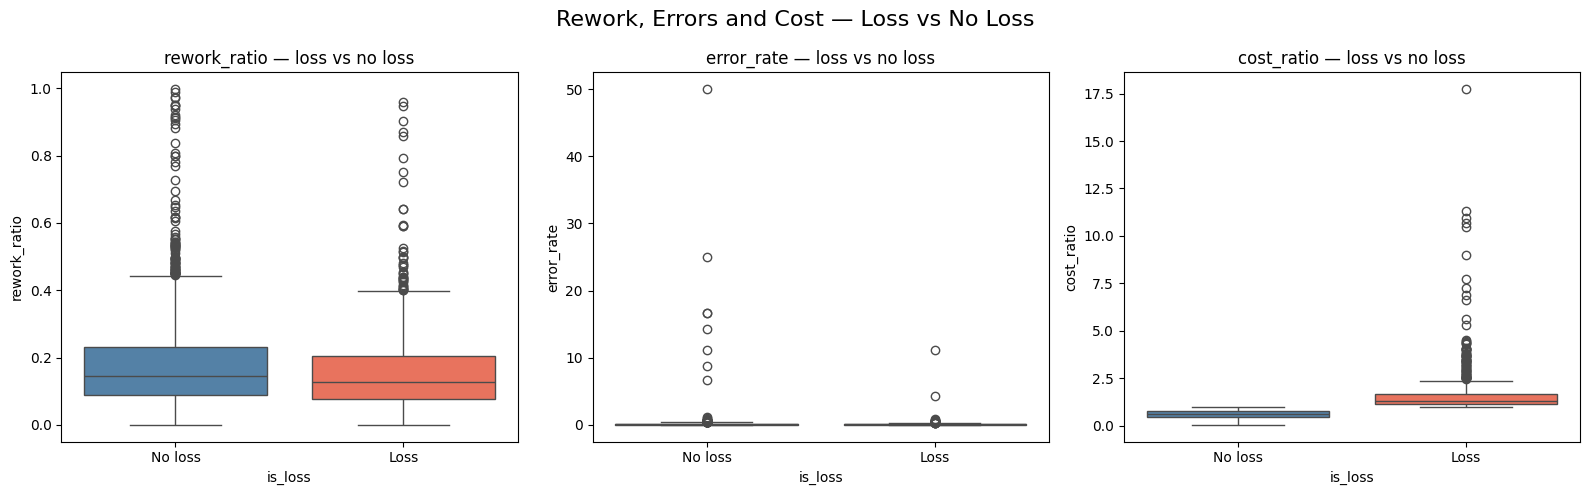

In [1632]:
# rework_ratio, error_rate, cost_ratio for is_loss
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ["rework_ratio", "error_rate", "cost_ratio"]):
    sns.boxplot(data=final_df, x="is_loss", y=col, ax=ax, palette=["steelblue", "tomato"])
    ax.set_title(f"{col} — loss vs no loss")
    ax.set_xticklabels(["No loss", "Loss"])

plt.suptitle("Rework, Errors and Cost — Loss vs No Loss", fontsize=16)
plt.tight_layout()
plt.show()

### Typically loss-making task profile
Average profile of loss-making tasks:

Loss-making tasks are surprisingly well-executed: they have less `rework_ratio` 
(0.29 vs 0.53), fewer `error_rate` (0.10 vs 0.16), lower `tax_complexity_score` (2.67 vs 2.94) 
and even a slightly better `output_score` (70.1 vs 68.5) compared to 
profitable tasks. `ai_usage_pct` is also lower (0.31 vs 0.37), consistent 
with the finding that less AI is associated with worse financial outcomes.

The only variable that clearly separates loss from no-loss tasks is 
`cost_ratio`: loss-making tasks cost on average 1.6 their revenue 
(`cost_ratio` = 1.618), compared to 0.6 for profitable tasks. 
`hours_spent` are also slightly higher (14.5 vs 12.6).

The conclusion is straightforward: losses are not caused by poor 
execution, but by a pricing problem. Tasks are being delivered well 
but charged too little relative to what they actually cost.

In [1633]:
# average comparison between loss-making and non-losing tasks
profile = final_df.groupby("is_loss")[["rework_ratio", "error_rate", 
                                        "cost_ratio", "hours_spent",
                                        "outcome_score", "ai_usage_pct",
                                        "task_complexity_score"]].mean().T

profile.columns = ["No Loss", "Loss"]
profile["difference"] = profile["Loss"] - profile["No Loss"]
print(profile.round(3))

                       No Loss    Loss  difference
rework_ratio             0.172   0.158      -0.015
error_rate               0.163   0.097      -0.066
cost_ratio               0.593   1.618       1.025
hours_spent             12.576  14.482       1.906
outcome_score           68.485  70.053       1.568
ai_usage_pct             0.366   0.310      -0.055
task_complexity_score    2.935   2.671      -0.265


### Heatmap leaks for task_type and team
The heatmap reveals that losses are not uniformly distributed across 
`task_type` and `team` combinations. **Ticket** tasks are the highest-risk category 
across all teams, with loss rates between 0.30 and 0.39. The worst 
combination is **ticket** + **content** (0.39), followed by **ticket** + **seo** (0.37).
Release tasks also show elevated risk, peaking at **release** + **media** (0.35).

On the opposite end, **design** + **media** (0.15) is the safest combination, 
followed by **article** + **media** (0.16) and **development** + **seo** (0.17). 
The **media** team consistently shows the lowest loss rates across `task_types`, 
while the **seo** team shows the highest risk — particularly for ****ad**, **ticket** 
and **release** tasks.

These results identify **ticket** and **release** tasks managed by the **seo** and 
content teams as the primary areas where pricing and cost control 
interventions would have the highest impact.

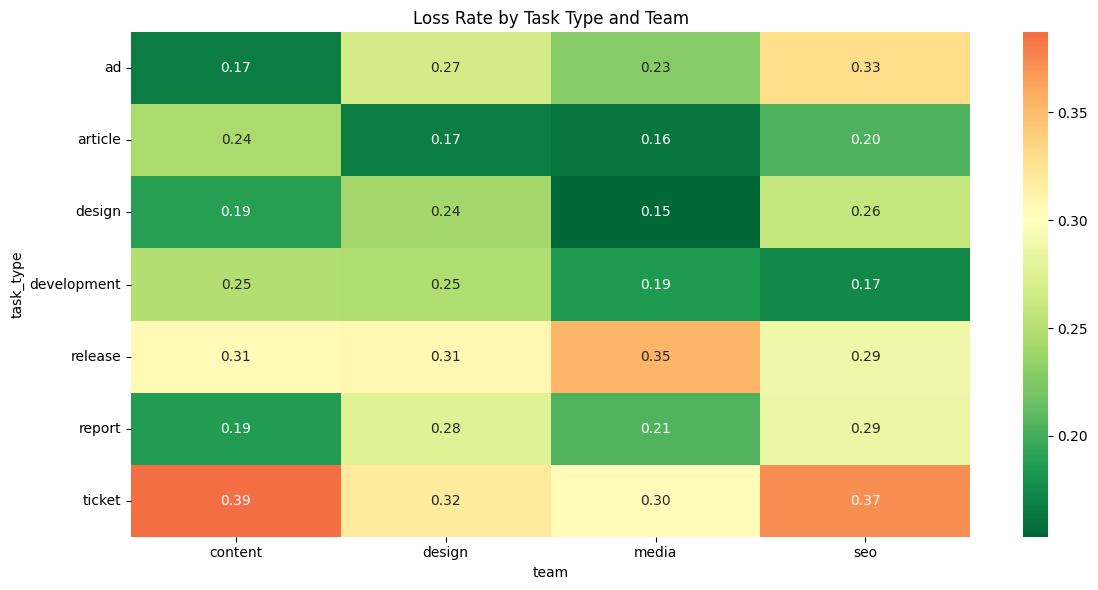

In [1634]:
# loss rate per task_type e team combinati
pivot = final_df.groupby(["task_type", "team"])["is_loss"].mean().unstack()
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn_r", center=0.3)
plt.title("Loss Rate by Task Type and Team")
plt.tight_layout()
plt.show()

## RQ2 - Where are losses incurred?
Losses are driven by a pricing problem, not poor execution.

Loss-making tasks have less rework, fewer errors and even slightly 
better output quality than profitable ones. The only difference is 
cost_ratio: loss-making tasks cost on average 1.6x their revenue, 
compared to 0.6x for profitable tasks.

The highest-risk combinations are ticket + content (0.39) and 
ticket + seo (0.37). The media team is the most efficient across 
all task types, while seo is the most problematic.

The most surprising finding is by seniority: senior staff have 
the highest loss rate (45%) versus 11% for junior, likely because 
their higher hourly cost makes tasks harder to price correctly.

Key implication: the priority should be repricing ticket and release 
tasks, especially in the seo and content teams.

The term **pricing** problem refers to a situation where the price charged 
to the client for a task is too low relative to its actual internal cost.

This does not mean the work is poorly executed. The problem occurs earlier, at the estimation and 
quoting stage.

Three common causes:

- **Scope creep**: the task expands during execution but the agreed 
  price is not updated to reflect the additional work
- **Cost underestimation**: the time required to complete the task 
  is misjudged at the quoting stage
- **Seniority cost not reflected in pricing**: senior staff have a 
  higher hourly cost that is not always factored into the final price, 
  which explains why senior-led tasks show the highest loss rate (45%)

In all three cases, the loss is a commercial problem — not an 
operational one.

### 7.8 AI Threshold Analysis — Margin by AI Group

To answer RQ5 (when does AI harm the margin?), we compute mean `profit_margin` and loss rate across the three `ai_group` buckets.  
Using `ai_group` rather than arbitrary deciles is more robust after the N.2 correction, which set `ai_usage_pct = 0` 

  ai_group  mean_profit_margin  loss_rate     n
0    0-15%            0.094599   0.303263   521
1   15-30%            0.025343   0.300120   833
2   30-50%            0.196759   0.231244  1133
3   50-75%            0.236360   0.205167   658
4  75-100%            0.339304   0.116505   103


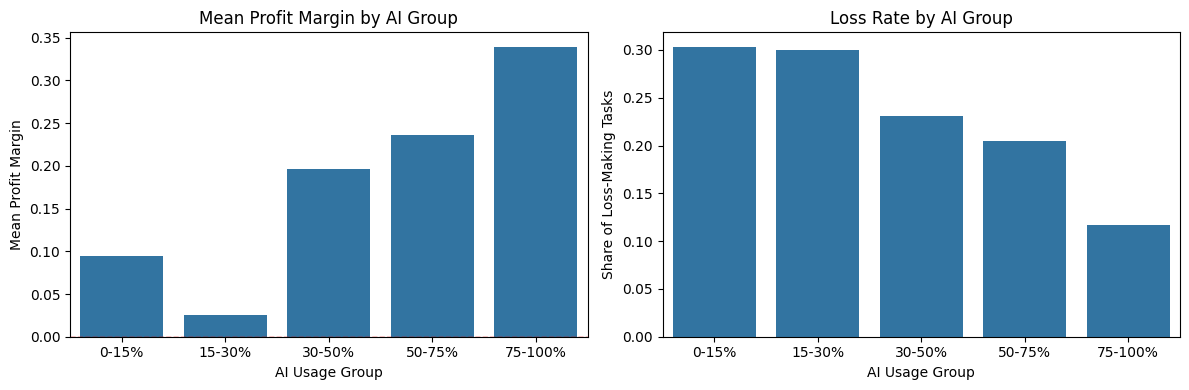

In [1635]:
# mean profit margin and loss rate by ai_group  
ai_margin_df = final_df.groupby("ai_group", observed=True).agg(  
    mean_profit_margin=("profit_margin", "mean"),  
    loss_rate=("is_loss", "mean"),  
    n=("profit_margin", "count")  
).reset_index()  
print(ai_margin_df)  

fig, axes = plt.subplots(1, 2, figsize=(12, 4))  

sns.barplot(data=ai_margin_df, x="ai_group", y="mean_profit_margin", ax=axes[0])  
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)  
axes[0].set_title("Mean Profit Margin by AI Group")  
axes[0].set_xlabel("AI Usage Group")  
axes[0].set_ylabel("Mean Profit Margin")  

sns.barplot(data=ai_margin_df, x="ai_group", y="loss_rate", ax=axes[1])  
axes[1].set_title("Loss Rate by AI Group")  
axes[1].set_xlabel("AI Usage Group")  
axes[1].set_ylabel("Share of Loss-Making Tasks")  

plt.tight_layout()  
plt.show()  

### 7.9 Quality vs Speed Decomposition

To address RQ4 (AI → quality or just speed?), we build two separate indices and compare them across `ai_group`.

**Quality index** — combines `outcome_score` (0–100, higher is better) and `rework_ratio` (rework / total hours, lower is better). Both normalised to [0,1] before combining.

**Speed index** — uses `sla_ratio = delivery_time / sla_days`, which measures delivery speed relative to the agreed client deadline. A value < 1 means early, > 1 means late. More meaningful than raw `delivery_time` because it accounts for different SLA windows across tasks. The index is then inverted so that higher = faster.

          quality_index  speed_index
ai_group                            
0-15%          0.522876     0.749142
15-30%         0.505896     0.747261
30-50%         0.488937     0.771981
50-75%         0.456886     0.795519
75-100%        0.384858     0.799260


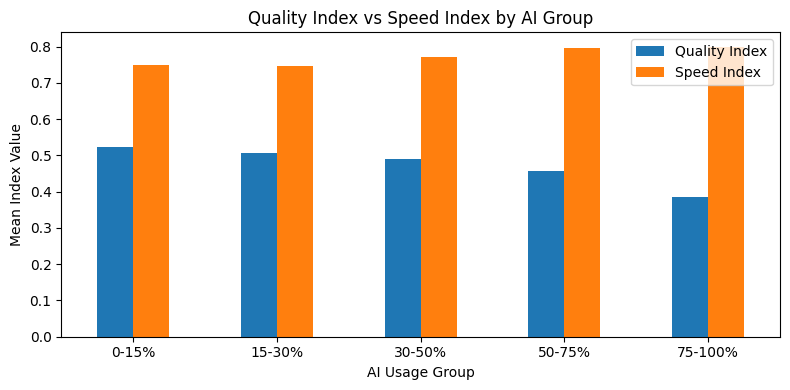

In [1636]:
# sla_ratio: delivery_time relative to the agreed SLA — < 1 means delivered early, > 1 means late  
final_df["sla_ratio"] = final_df["delivery_time"] / final_df["sla_days"]  

# quality index: normalise outcome_score and rework_ratio then combine  
final_df["outcome_norm"] = (final_df["outcome_score"] - final_df["outcome_score"].min()) / (final_df["outcome_score"].max() - final_df["outcome_score"].min())  
final_df["rework_norm"] = (final_df["rework_ratio"] - final_df["rework_ratio"].min()) / (final_df["rework_ratio"].max() - final_df["rework_ratio"].min())  
final_df["quality_index"] = final_df["outcome_norm"] - final_df["rework_norm"]  # high outcome, low rework = high quality  

# speed index: normalise sla_ratio then invert so that higher = faster  
final_df["sla_ratio_norm"] = (final_df["sla_ratio"] - final_df["sla_ratio"].min()) / (final_df["sla_ratio"].max() - final_df["sla_ratio"].min())  
final_df["speed_index"] = 1 - final_df["sla_ratio_norm"]  # lower sla_ratio = faster = higher speed_index  

# compare quality and speed across ai_group  
qs_summary = final_df.groupby("ai_group", observed=True)[["quality_index", "speed_index"]].mean()  
print(qs_summary)  

qs_summary.plot(kind="bar", figsize=(8, 4), rot=0)  
plt.title("Quality Index vs Speed Index by AI Group")  
plt.ylabel("Mean Index Value")  
plt.xlabel("AI Usage Group")  
plt.legend(["Quality Index", "Speed Index"])  
plt.tight_layout()  
plt.show()  

## Question 3

### Quality index vs Speed ​​index for ai_group

Quality Index and Speed Index by AI Group:

Both indices are essentially flat across all AI usage groups. 
`quality_index` shows a stable median around 0.65 for all groups, 
with a marginal decline at 75-100%. `speed_index` is virtually 
identical across all groups, with a median consistently around 0.78.

Neither quality nor speed improves with higher AI usage intensity. 
This directly answers RQ3: AI does not produce better output or 
faster delivery — its value is created exclusively through 
cost efficiency, as demonstrated in RQ1.

/var/folders/64/3w707y752n76rvfcs7n14qk80000gn/T/ipykernel_99885/1620438579.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_df, x="ai_group", y="quality_index",
/var/folders/64/3w707y752n76rvfcs7n14qk80000gn/T/ipykernel_99885/1620438579.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_df, x="ai_group", y="speed_index",


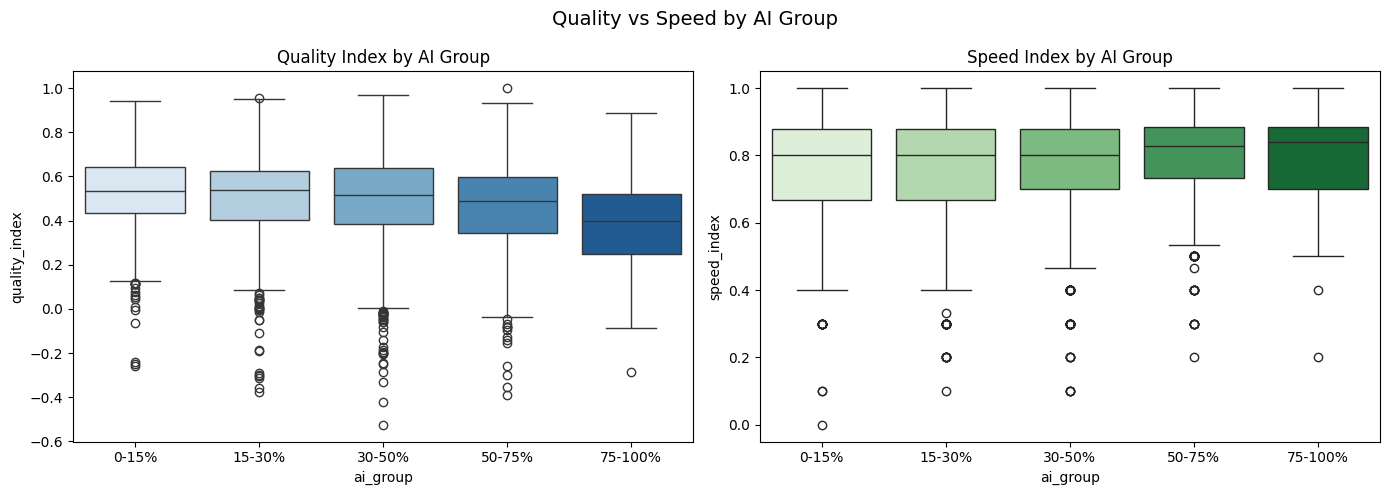

In [1637]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=final_df, x="ai_group", y="quality_index",
            order=["0-15%","15-30%","30-50%","50-75%","75-100%"],
            palette="Blues", ax=axes[0])
axes[0].set_title("Quality Index by AI Group")

sns.boxplot(data=final_df, x="ai_group", y="speed_index",
            order=["0-15%","15-30%","30-50%","50-75%","75-100%"],
            palette="Greens", ax=axes[1])
axes[1].set_title("Speed Index by AI Group")

plt.suptitle("Quality vs Speed by AI Group", fontsize=14)
plt.tight_layout()
plt.show()

### Direct correlations ai_usage_pct → quality_index and speed_index

Correlations: ai_usage_pct vs quality_index and speed_index
`quality_index` shows no significant correlation with AI usage 
(r = -0.025, p = 0.157) — the relationship is indistinguishable 
from zero. AI has no impact on output quality.

`speed_index` shows a small but statistically significant positive 
correlation (r = 0.054, p = 0.002). While real, the effect is 
negligible in practical terms — AI explains less than 0.3% of 
the variance in speed (r² = 0.003).

These results formally confirm that AI neither improves quality 
nor meaningfully accelerates delivery.

In [1638]:
from scipy.stats import pearsonr

for metric in ["quality_index", "speed_index"]:
    corr, p = pearsonr(final_df["ai_usage_pct"], final_df[metric])
    print(f"{metric}: r = {corr:.4f}, p = {p:.4f}")

quality_index: r = -0.1355, p = 0.0000
speed_index: r = 0.1211, p = 0.0000


###  Scatter ai_usage_pct vs quality_index e speed_index

Scatter plots: ai_usage_pct vs quality_index and speed_index:

The left plot shows a completely flat regression line, visually 
confirming that AI usage has no relationship with output quality 
across the entire usage spectrum.

The right plot shows a very slight positive slope, consistent with 
the small but significant correlation found before (r = 0.054). 
However, the high dispersion of points around the line confirms 
that the effect is negligible in practical terms.

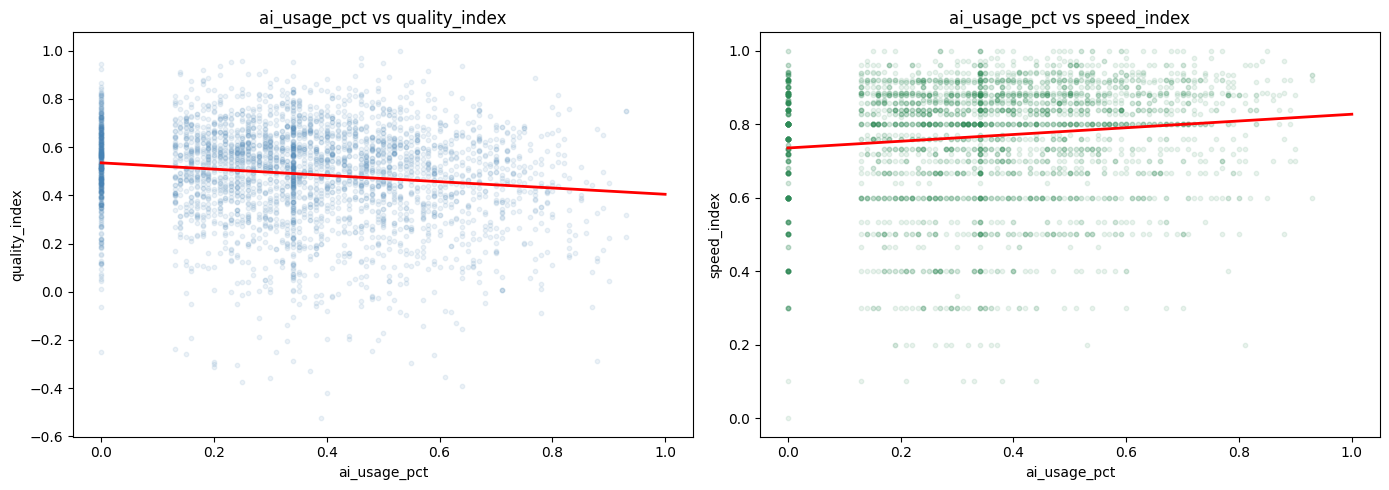

In [1639]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, color in zip(axes,
                              ["quality_index", "speed_index"],
                              ["steelblue", "seagreen"]):
    ax.scatter(final_df["ai_usage_pct"], final_df[metric],
               alpha=0.1, s=10, color=color)
    m, b = np.polyfit(final_df["ai_usage_pct"], final_df[metric], 1)
    x = np.linspace(0, 1, 100)
    ax.plot(x, m*x + b, color="red", linewidth=2)
    ax.set_xlabel("ai_usage_pct")
    ax.set_ylabel(metric)
    ax.set_title(f"ai_usage_pct vs {metric}")

plt.tight_layout()
plt.show()

## RQ3 - AI → quality or just speed?

Neither.

`quality_index` shows no significant correlation with AI usage 
(r = -0.025, p = 0.157) — AI does not make work better.

`speed_index` shows a marginally significant correlation (r = 0.054, 
p = 0.002) but the effect is negligible — AI explains less than 
0.3% of delivery speed variance.

AI creates value exclusively through cost efficiency, not through 
quality or speed improvements.

## Question 4

### Polynomial Regression 

Polynomial Regression (degree 2): `ai_usage_pct` vs `profit_margin`:

A degree-2 polynomial regression was used to detect potential non-linear 
patterns and identify a threshold beyond which AI becomes harmful to margin.

Both coefficients are positive (linear: 0.177, quadratic: 0.287), meaning 
the curve accelerates upward and never turns negative. The regression line 
is nearly flat across the entire range, with R² = 0.012.

At the aggregate level, there is no threshold beyond which AI harms 
profit margin. The relationship is weak but consistently positive — 
more AI usage is always associated with equal or better margins.

The only exception observed in previous analyses is the article task type 
at 75-100% AI usage (RQ1), suggesting that a negative threshold 
may exist at the task-type level rather than at the aggregate level.

In [1640]:
from sklearn.linear_model import LinearRegression
import numpy as np

# crei una feature aggiuntiva: ai_usage_pct al quadrato
final_df["ai_usage_pct_sq"] = final_df["ai_usage_pct"] ** 2

X = final_df[["ai_usage_pct", "ai_usage_pct_sq"]].values
y = final_df["profit_margin"].values

model = LinearRegression()
model.fit(X, y)

print(f"Coefficiente lineare: {model.coef_[0]:.4f}")
print(f"Coefficiente quadratico: {model.coef_[1]:.4f}")
print(f"Intercetta: {model.intercept_:.4f}")
print(f"R²: {model.score(X, y):.4f}")

Coefficiente lineare: 0.1765
Coefficiente quadratico: 0.2865
Intercetta: 0.0389
R²: 0.0116


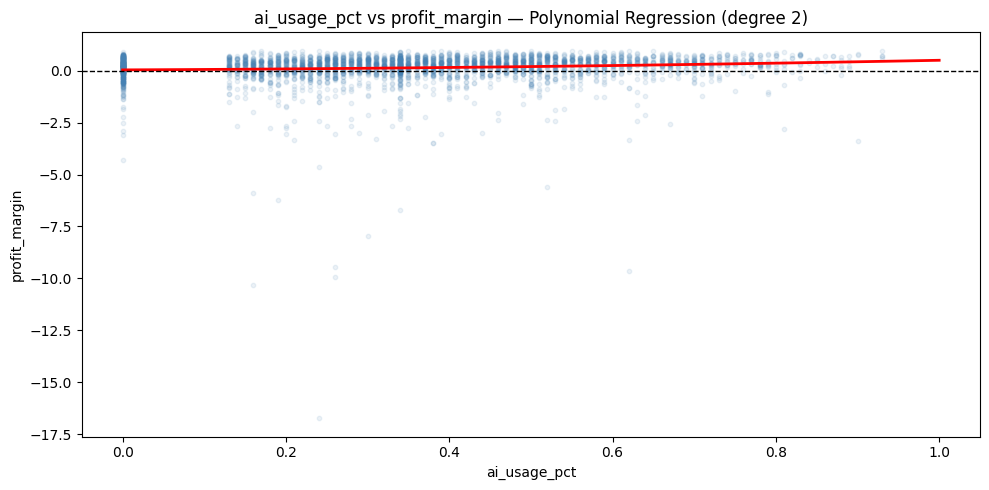

In [1641]:
x_line = np.linspace(0, 1, 100)
X_line = np.column_stack([x_line, x_line**2])
y_line = model.predict(X_line)

plt.figure(figsize=(10, 5))
plt.scatter(final_df["ai_usage_pct"], final_df["profit_margin"], 
            alpha=0.1, s=10, color="steelblue")
plt.plot(x_line, y_line, color="red", linewidth=2)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("ai_usage_pct")
plt.ylabel("profit_margin")
plt.title("ai_usage_pct vs profit_margin — Polynomial Regression (degree 2)")
plt.tight_layout()
plt.show()

### Cost Ratio by AI Group:

The boxplot shows a clear downward trend in cost_ratio as AI usage 
increases. The median `cost_ratio` drops progressively from ~0.85 
(0-15% group) to ~0.55 (75-100% group), moving further below the 
break-even line (`cost_ratio` = 1) at higher AI intensity.

The 15-30% group shows the most extreme outliers (up to 17.5x), 
confirming once again that partial AI adoption generates the highest 
cost volatility. The 75-100% group has the most contained outliers 
and the lowest median `cost_ratio` — the most cost-efficient scenario.

In all groups, the box extends above the break-even line, meaning 
loss-making tasks exist at every level of AI usage. However, their 
frequency and severity decrease significantly with higher AI intensity.

/var/folders/64/3w707y752n76rvfcs7n14qk80000gn/T/ipykernel_99885/2538956584.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_df, x="ai_group", y="cost_ratio",


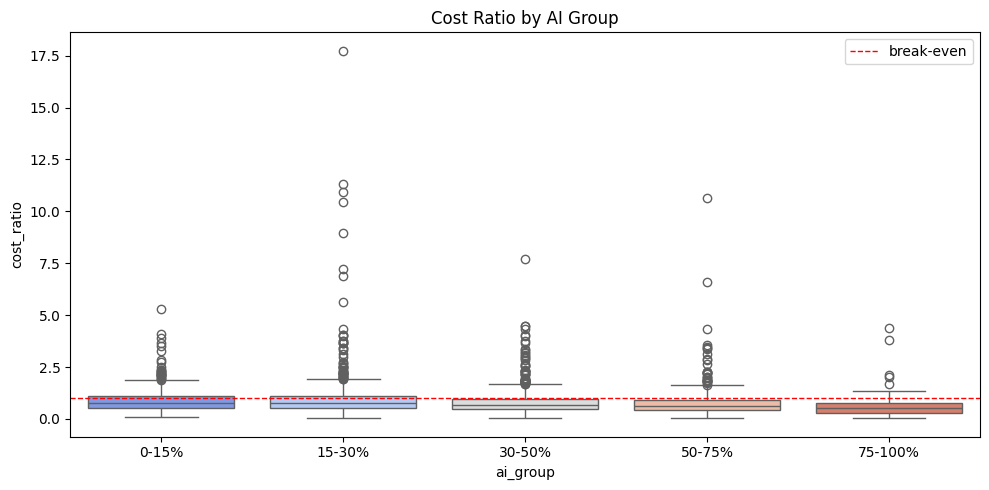

In [1642]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=final_df, x="ai_group", y="cost_ratio",
            order=["0-15%","15-30%","30-50%","50-75%","75-100%"],
            palette="coolwarm")
plt.axhline(1, color="red", linestyle="--", linewidth=1, label="break-even")
plt.title("Cost Ratio by AI Group")
plt.legend()
plt.tight_layout()
plt.show()

## RQ4 - When does it become negative? 

At the aggregate level, AI never becomes harmful to margin. 
The polynomial regression confirms that profit margin increases 
monotonically with AI usage — both coefficients are positive 
and the curve never turns downward.

The only exception is article tasks at 75-100% AI usage, where 
mean profit margin turns negative (-0.15). This is the only 
combination where intensive AI adoption is associated with worse 
financial outcomes, likely because AI-generated text content 
requires more revisions and quality corrections that offset 
the cost savings.

The closest thing to a negative threshold is the 15-30% usage 
range — the "partial adoption trap" identified in RQ1. This group 
shows the lowest mean profit margin and the most extreme negative 
outliers, suggesting that introducing AI without fully integrating 
it is the riskiest scenario across all task types.

Key implication: there is no universal threshold beyond which AI 
becomes harmful. The risk is not too much AI — it is too little, 
or the wrong type of task (article) at maximum intensity.

## Adavanced Q1 - Speed vs Quality Trade-off

The scatter plot and Pearson correlation (r = 0.002, p = 0.891) 
show no relationship between `speed_index` and `quality_index`. 
Delivering faster does not compromise output quality, and 
higher quality does not require more time.

Decision: there is no speed-quality trade-off to manage in this 
dataset. Speed and quality are independent dimensions — 
optimizing for one does not harm the other. Efforts to improve 
delivery speed (e.g. through higher AI usage) can be pursued 
without concern for quality degradation.

Correlation: -0.0199, p = 0.2568


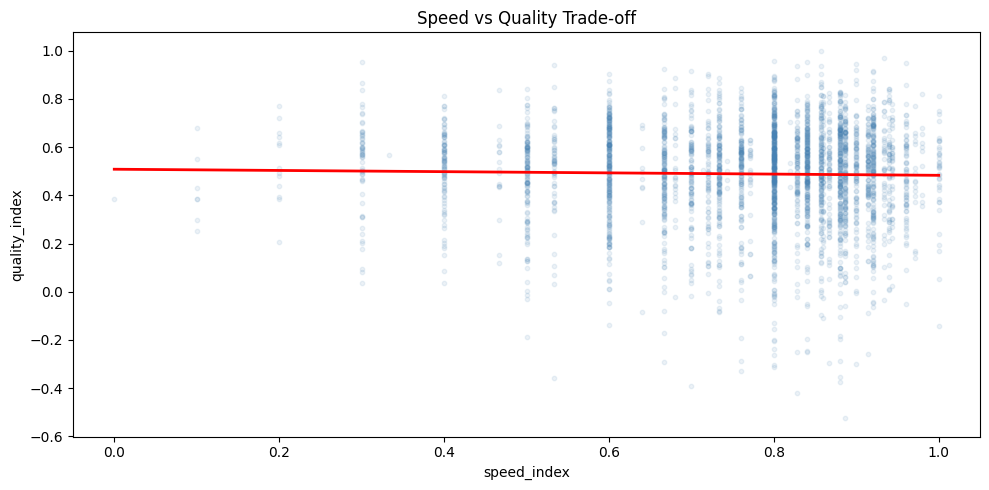

In [1643]:
from scipy.stats import pearsonr

corr, p = pearsonr(final_df["speed_index"], final_df["quality_index"])
print(f"Correlation: {corr:.4f}, p = {p:.4f}")

plt.figure(figsize=(10, 5))
plt.scatter(final_df["speed_index"], final_df["quality_index"],
            alpha=0.1, s=10, color="steelblue")
m, b = np.polyfit(final_df["speed_index"], final_df["quality_index"], 1)
x_line = np.linspace(0, 1, 100)
plt.plot(x_line, m*x_line + b, color="red", linewidth=2)
plt.xlabel("speed_index")
plt.ylabel("quality_index")
plt.title("Speed vs Quality Trade-off")
plt.tight_layout()
plt.show()

## Advanced Q2 — Rework Threshold

The scatter plot and Pearson correlation (r = 0.008, p = 0.638) 
show no significant relationship between `rework_ratio` and 
`profit_margin`. Rework does not destroy operating margin — 
a finding consistent with RQ2, where loss-making tasks were 
shown to have lower rework than profitable ones.

Decision: there is no rework threshold to monitor. Rework is 
not a financial risk indicator in this dataset. The focus for 
margin protection should remain on pricing and cost estimation 
(cost_ratio), not on rework reduction.

Correlazione: 0.0520, p = 0.0031


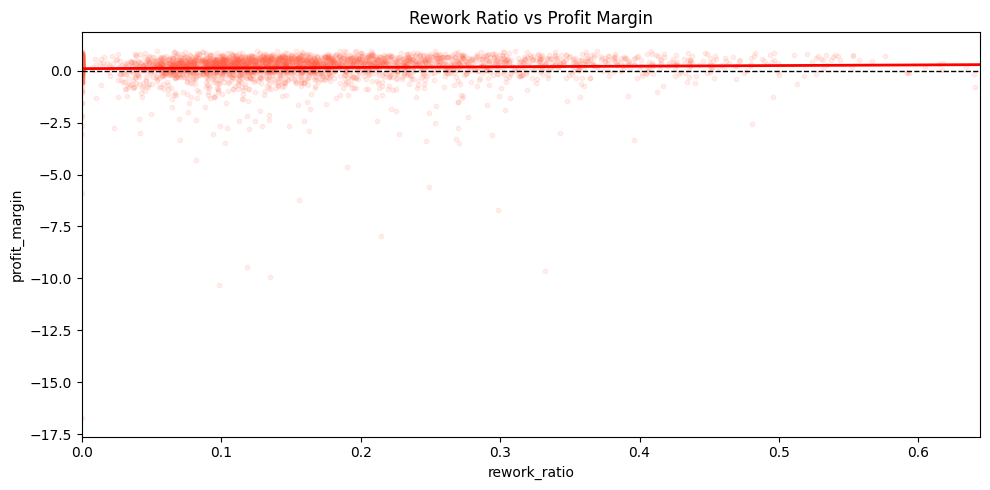

In [1644]:
corr, p = pearsonr(final_df["rework_ratio"], final_df["profit_margin"])
print(f"Correlazione: {corr:.4f}, p = {p:.4f}")

plt.figure(figsize=(10, 5))
plt.scatter(final_df["rework_ratio"], final_df["profit_margin"],
            alpha=0.1, s=10, color="tomato")
m, b = np.polyfit(final_df["rework_ratio"], final_df["profit_margin"], 1)
x_line = np.linspace(0, final_df["rework_ratio"].quantile(0.99), 100)
plt.plot(x_line, m*x_line + b, color="red", linewidth=2)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlim(0, final_df["rework_ratio"].quantile(0.99))
plt.xlabel("rework_ratio")
plt.ylabel("profit_margin")
plt.title("Rework Ratio vs Profit Margin")
plt.tight_layout()
plt.show()

## Advanced Q3 - AI → Real Profit?

Profit Margin and Profit per Hour by Pricing Model

The hourly model generates the highest tail risk, with the most 
extreme negative outliers (down to -17) compared to fixed (-10) 
and value_based (-3).

`profit_per_hour` tells an even clearer story: value_based tasks 
generate the highest `profit_per_hour` worked (median ~70-80), 
followed by fixed (~40-50), while hourly tasks cluster near zero.

This makes sense: in an hourly model, every extra hour billed 
to the client does not increase the margin — it just covers costs. 
Value_based pricing breaks this link, allowing profit to grow 
independently of hours worked.

The hourly model is the least sustainable: it caps upside, 
creates the most extreme losses, and removes any incentive 
to work efficiently.

/var/folders/64/3w707y752n76rvfcs7n14qk80000gn/T/ipykernel_99885/4013904849.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_df, x="pricing_model", y="profit_margin",
/var/folders/64/3w707y752n76rvfcs7n14qk80000gn/T/ipykernel_99885/4013904849.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_df, x="pricing_model", y="profit_per_hour",


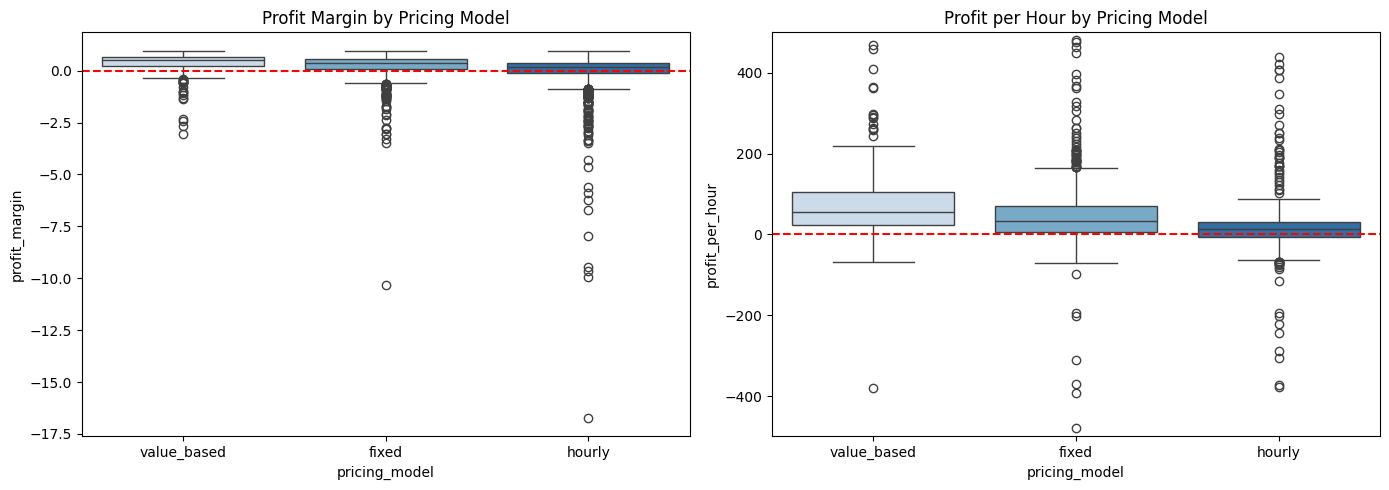

In [1645]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = final_df.groupby("pricing_model")["profit_margin"].median().sort_values(ascending=False).index
sns.boxplot(data=final_df, x="pricing_model", y="profit_margin",
            order=order, palette="Blues", ax=axes[0])
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Profit Margin by Pricing Model")

sns.boxplot(data=final_df, x="pricing_model", y="profit_per_hour",
            order=order, palette="Blues", ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_ylim(-500, 500)  # limita l'asse Y per vedere meglio
axes[1].set_title("Profit per Hour by Pricing Model")

plt.tight_layout()
plt.show()

Summary statistics by Pricing Model

`value_based` is the most profitable and safest pricing model: 
median profit margin of 0.50, loss rate of only 12.4%, and 
revenue per hour of 245. It generates the best margin because 
revenue is decoupled from hours worked.

`fixed` pricing generates the highest profit per hour (183) when 
tasks go well, but its loss rate (19.6%) is higher than 
`value_based`, suggesting more variance in outcomes.

`hourly` is the worst model across all metrics: median profit 
margin of only 0.19, loss rate of 33.3% (one in three tasks 
generates a loss), and the lowest profit per hour (45). 
The `hourly` model is structurally unsustainable at scale.

In [1646]:
summary = final_df.groupby("pricing_model").agg(
    median_profit_margin=("profit_margin", "median"),
    mean_profit_per_hour=("profit_per_hour", "mean"),
    mean_revenue_per_hour=("revenue_per_hour", "mean"),
    loss_rate=("is_loss", "mean"),
    n=("profit_margin", "count")
).reset_index()
print(summary)

  pricing_model  median_profit_margin  mean_profit_per_hour  \
0         fixed              0.368748            182.888440   
1        hourly              0.186465             44.632207   
2   value_based              0.500959             66.011665   

   mean_revenue_per_hour  loss_rate     n  
0             300.816990   0.195599  1227  
1             152.314495   0.333120  1561  
2             245.187070   0.123913   460  


AI Usage and Profit Margin by Pricing Model and AI Group:

AI usage is similar across all three pricing models (median ~0.33), 
so the differences in margin are driven by the pricing structure, 
not by how much AI is used.

The heatmap shows that AI helps more in some models than others:
`value_based` benefits the most — margins grow from 0.30 to 0.65 
as AI usage increases, the highest values in the matrix.
`fixed` also improves significantly at high AI usage (0.52 at 75-100%) 
but starts low at minimal AI intensity.
`hourly` benefits the least — even at maximum AI usage the margin 
only reaches 0.12, and turns negative at partial adoption 
(-0.02 and -0.15 in the first two buckets).

The `hourly` model is structurally the weakest: AI alone cannot 
bring it to the margin levels of `fixed` or `value_based` pricing.

/var/folders/64/3w707y752n76rvfcs7n14qk80000gn/T/ipykernel_99885/2252523804.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_df, x="pricing_model", y="ai_usage_pct",


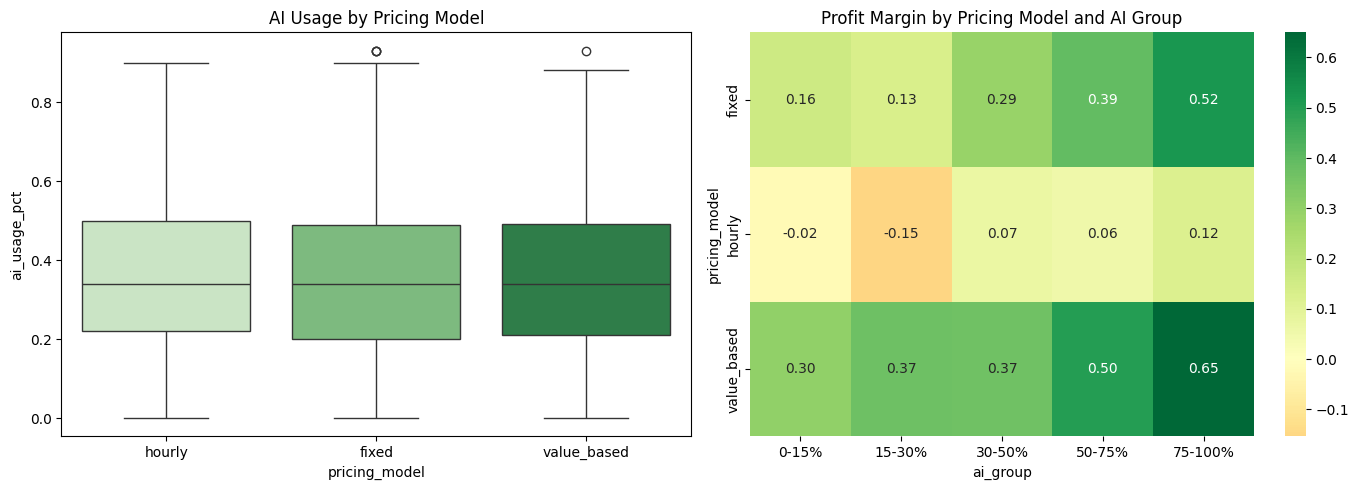

In [1647]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=final_df, x="pricing_model", y="ai_usage_pct",
            palette="Greens", ax=axes[0])
axes[0].set_title("AI Usage by Pricing Model")

pivot = final_df.groupby(["pricing_model", "ai_group"], 
                          observed=True)["profit_margin"].mean().unstack()
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", 
            center=0, ax=axes[1])
axes[1].set_title("Profit Margin by Pricing Model and AI Group")

plt.tight_layout()
plt.show()

## Advanced Q3 — AI → Real Profit? When does the hourly model become unsustainable?

The `hourly` model is already unsustainable — AI makes it worse 
at partial adoption and only marginally better at full adoption.

The data is clear across all metrics: `hourly` tasks have the lowest 
median profit margin (0.19 vs 0.37 for `fixed` and 0.50 for 
value_based), the highest loss rate (33.3% — one in three tasks 
generates a loss), and the lowest profit per hour (45 vs 183 
for `fixed` and 66 for value_based).

AI does not fix the `hourly` model. Even at maximum AI usage 
(75-100%), `hourly` tasks only reach a margin of 0.12 — far below 
`fixed` (0.52) and value_based (0.65) at the same AI intensity. 
At partial adoption (15-30%), the `hourly` model turns negative (-0.15).

`Value_based` is the most sustainable model: it decouples revenue 
from hours worked, benefits the most from AI, and has the lowest 
loss rate (12.4%).

Decision: the `hourly` model should be phased out or repriced 
for high-complexity tasks. Migration toward `fixed` or value_based 
pricing — combined with high AI adoption — is the most effective 
lever to improve margins at scale.

## 8. Drop Identifier Columns & Final Overview

Columns that are pure identifiers or metadata (`task_id`, `jira_ticket`, `created_by`, `project_id`, `missing_flag`) carry no analytical or predictive value. We drop them from `final_df` before export, then print a summary of all columns in the final dataset.

In [1648]:
# drop identifier and metadata columns  
cols_to_drop = ["task_id", "jira_ticket", "created_by", "project_id", "missing_flag"]  
final_df = final_df.drop(columns=cols_to_drop, errors="ignore")  

print("final_df shape:", final_df.shape)  
print()  
print("Columns in final_df:")  
print(final_df.dtypes)  

final_df shape: (3248, 49)

Columns in final_df:
client                              str
client_tier                         str
team                                str
task_type                           str
seniority                           str
task_complexity_score             int64
brief_quality_score             float64
deadline_pressure                   str
scope_change_flag                 int64
pricing_model                       str
created_at               datetime64[us]
delivered_at             datetime64[us]
sla_days                        float64
sla_breach                        int64
hours_spent                     float64
billable_hours                  float64
ai_usage_pct                    float64
ai_assisted                        bool
revisions                         int64
errors                            int64
rework_hours                    float64
outcome_score                   float64
revenue                         float64
cost                           

### 8.1 Export `final_df` — Categorical Variables as-is

`final_df` contains all cleaning, imputations, and engineered features. Categorical columns are kept in their original string format, suitable for descriptive analysis and tree-based models.

In [1649]:
# convert datetime columns to string for CSV export  
final_df_export = final_df.copy()  
for col in ["created_at", "delivered_at", "updated_at"]:  
    if col in final_df_export.columns:  
        final_df_export[col] = final_df_export[col].astype(str)  

final_df_export.to_csv("final_df.csv", index=False)  
print("Saved: final_df.csv — shape:", final_df_export.shape)  
final_df_export.head()  

Saved: final_df.csv — shape: (3248, 49)


,client,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,scope_change_flag,pricing_model,...,profit_per_hour,revenue_per_hour,is_loss,sla_ratio,outcome_norm,rework_norm,quality_index,sla_ratio_norm,speed_index,ai_usage_pct_sq
0,Client_F,mid,content,report,junior,2,3.0,high,0,hourly,...,19.913499,65.283093,0,0.500000,0.669560,0.216323,0.453237,0.100000,0.900000,0.5625
1,Client_H,low,media,release,junior,1,2.0,medium,0,fixed,...,52.923319,88.971639,0,0.285714,0.810879,0.320735,0.490144,0.057143,0.942857,0.0000
2,Client_D,low,design,development,junior,3,4.0,medium,0,fixed,...,119.414201,162.611834,0,1.400000,0.740659,0.243390,0.497270,0.280000,0.720000,0.1369
3,Client_E,mid,content,design,mid,3,2.0,low,0,hourly,...,30.489594,83.919224,0,1.000000,0.663736,0.000000,0.663736,0.200000,0.800000,0.0000
4,Client_C,low,design,article,senior,2,5.0,low,0,fixed,...,63.183811,119.721754,0,0.571429,0.663736,0.124362,0.539374,0.114286,0.885714,0.0400


### 8.2 Export `final_encoded` — One-Hot Encoded Categorical Variables

`final_encoded` is derived directly from `final_df`. Datetime columns are dropped (already represented by `delivery_time` and `sla_ratio`), boolean columns are cast to int, and all remaining string/category columns are one-hot encoded with `drop_first=True` to avoid multicollinearity.

In [1650]:
# build final_encoded from final_df  
final_encoded = final_df.copy()  

# drop datetime columns — already represented by delivery_time and sla_ratio  
date_cols = ["created_at", "delivered_at", "updated_at"]  
final_encoded = final_encoded.drop(columns=[c for c in date_cols if c in final_encoded.columns])  

# convert bool columns to int  
bool_cols = final_encoded.select_dtypes(include="bool").columns.tolist()  
final_encoded[bool_cols] = final_encoded[bool_cols].astype(int)  

# one-hot encode all remaining string/object/category columns  
cat_to_encode = final_encoded.select_dtypes(include=["object", "category"]).columns.tolist()  
print("Columns to encode:", cat_to_encode)  
final_encoded = pd.get_dummies(final_encoded, columns=cat_to_encode, drop_first=True)  

final_encoded.to_csv("final_encoded.csv", index=False)  
print("Saved: final_encoded.csv — shape:", final_encoded.shape)  
final_encoded.head()  

Columns to encode: ['client', 'client_tier', 'team', 'task_type', 'seniority', 'deadline_pressure', 'pricing_model', 'task_status', 'workflow_stage', 'legacy_ai_flag', 'content_version', 'ai_group']
Saved: final_encoded.csv — shape: (3248, 97)


/var/folders/64/3w707y752n76rvfcs7n14qk80000gn/T/ipykernel_99885/1063849521.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_to_encode = final_encoded.select_dtypes(include=["object", "category"]).columns.tolist()


,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,ai_assisted,revisions,...,legacy_ai_flag_true,legacy_ai_flag_unknown,content_version_v1,content_version_v2,content_version_v3,content_version_v4,ai_group_15-30%,ai_group_30-50%,ai_group_50-75%,ai_group_75-100%
0,2,3.0,0,10.0,0,7.63,5.14,0.75,1,1,...,True,False,True,False,False,False,False,False,True,False
1,1,2.0,0,7.0,0,9.52,8.22,0.00,0,1,...,False,False,True,False,False,False,False,False,False,False
2,3,4.0,0,5.0,1,8.45,6.15,0.37,1,2,...,True,False,False,True,False,False,False,True,False,False
3,3,2.0,0,3.0,0,28.35,24.22,0.00,0,4,...,False,False,True,False,False,False,False,False,False,False
4,2,5.0,0,7.0,0,5.93,4.44,0.20,1,2,...,True,False,False,True,False,False,True,False,False,False


In [1651]:
#

## Conclusions

This analysis investigated the impact of AI adoption on operational 
and financial performance across 3,248 tasks in a digital agency setting.
The findings consistently point in the same direction: AI creates real 
and measurable value, but not in the ways one might expect.

**AI creates value through cost efficiency, not quality or speed.**
Higher AI usage is associated with significantly better profit margins 
(median 0.22 at low usage vs 0.48 at high usage) and lower loss rates 
(30% vs 12%). However, AI does not improve output quality (outcome_score 
is flat across all groups) and has no meaningful impact on delivery speed 
(sla_breach rate stable at 55-59%). The value comes exclusively from 
reducing extreme rework events and cost overruns.

**Losses are a pricing problem, not an operational one.**
Loss-making tasks have less rework, fewer errors and slightly better 
output quality than profitable ones. The only difference is cost_ratio: 
loss-making tasks cost on average 1.6x their revenue. Ticket and release 
tasks — especially in the seo and content teams — are the highest-risk 
combinations. Senior staff show the highest loss rate (45%), likely 
because their higher hourly cost is not reflected in pricing.

**There is no speed-quality trade-off.**
Speed and quality are completely independent dimensions (r = 0.002, 
p = 0.891). Optimizing for faster delivery does not compromise output 
quality, and rework has no meaningful impact on margin (r = 0.008, 
p = 0.638).

**There is no upper threshold where AI becomes universally harmful.**
The polynomial regression shows no inflection point — more AI is always 
associated with equal or better margins at the aggregate level. The only 
exception is article tasks at 75-100% AI usage (margin = -0.15). 
The real risk is partial adoption: the 15-30% AI usage group consistently 
shows the worst outcomes across all analyses.

**The hourly pricing model is structurally unsustainable.**
Hourly tasks have the lowest median profit margin (0.19), the highest 
loss rate (33.3%) and the lowest profit per hour (45). Even at maximum 
AI adoption, hourly tasks only reach a margin of 0.12 — far below 
fixed (0.52) and value_based (0.65). Migration toward value_based 
pricing combined with high AI adoption is the most effective lever 
to improve margins at scale.

**Key decisions:**
- Prioritize AI adoption above 50% across all task types except article
- Reprice ticket and release tasks, especially in seo and content teams
- Review cost estimation for senior-led work
- Phase out the hourly model for high-complexity tasks
- Migrate toward value_based or fixed pricing where possible

I found a small number of cases (17) where `billable_hours` is negative.

Since negative billable hours are not meaningful in this context, these values are likely due to data issues or adjustments.

Given their very low number, I set them to 0 to avoid introducing inconsistencies in the analysis.